In [1]:
import os
import gc
import copy
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from torch import nn
from torch.optim import Adam
from torchvision import models
import torch.nn.functional as F
from torchvision.transforms import v2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, ConcatDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torchinfo import summary

In [2]:
# Check accelerator

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu'
print(f'Using {device} device')

Using cuda device


In [3]:
# Set SEED for reproducibility

SEED = 24520152

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Train directory path

TRAIN_DIR = '/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'
TRAIN_DIR

'/kaggle/input/5-fold-brain-tumor-contrast-enhanced/kfold_dataset'

In [5]:
# Save directory path

SAVE_DIR = '/kaggle/working/'
SAVE_DIR

'/kaggle/working/'

In [6]:
# 3 labels: Glioma Tumor, Meningioma Tumor, Pituitary Tumor

CLASS_NAMES = sorted([d for d in os.listdir(os.path.join(TRAIN_DIR, 'Subset_1')) if os.path.isdir(os.path.join(TRAIN_DIR, 'Subset_1', d))])
CLASS_NAMES

['Glioma Tumor', 'Meningioma Tumor', 'Pituitary Tumor']

In [7]:
# Model name

MODEL_NAME = 'ResNet50'
MODEL_NAME

'ResNet50'

In [8]:
# Hyperparameters

BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 3
DROPOUT_RATE = 0.3

In [9]:
def get_data_for_fold(k: int, train_dir: str = TRAIN_DIR, batch_size: int = BATCH_SIZE) -> tuple[DataLoader, DataLoader]:
    """
    Creates PyTorch DataLoaders for K-Fold Cross-Validation, specifically tailored
    for ResNet50 transfer learning with ImageNet standards.

    This function sets up a data pipeline that:
    1. Applies standard ImageNet normalization statistics.
    2. Implements strong data augmentation for the training set (using torchvision v2).
    3. Prepares validation data with deterministic preprocessing (Resize -> CenterCrop).
    4. Handles subset selection based on the current fold index 'k'.

    Args:
        k (int): The index of the validation fold (e.g., 1 to 5). 
                 The folder 'Subset_{k}' will be used for validation, while 
                 all other subsets are concatenated for training.
        train_dir (str): Path to the root directory containing the fold subsets 
                         (e.g., 'Subset_1', 'Subset_2', etc.).
        batch_size (int, optional): Number of samples per batch. Defaults to 32.

    Returns:
        tuple: A tuple containing:
            - train_loader (DataLoader): The training data loader (shuffled).
            - val_loader (DataLoader): The validation data loader (not shuffled).
    """

    # Standard ImageNet normalization statistics (Required for ResNet50 weights)
    norm_mean=[0.485, 0.456, 0.406]
    norm_std=[0.229, 0.224, 0.225]

    # Training Transform Pipeline
    train_transform = v2.Compose([
        # Resize to 256x256 first. This provides a buffer for subsequent 
        # rotation/translation and cropping, preventing black border artifacts.
        v2.Resize(size=256),

        # Apply Data Augmentation
        v2.RandomHorizontalFlip(),
        v2.RandomRotation(degrees=36),
        v2.RandomAffine(degrees=0, scale=(0.9, 1.1)),
        v2.ColorJitter(brightness=0.1, contrast=0.1),

        # Use CenterCrop to focus on the primary subject
        v2.CenterCrop(size=224),

        # Convert PIL/Numpy to Tensor, cast to Float32, and rescale to [0, 1]
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),

        # Normalize using ImageNet mean and std
        v2.Normalize(mean=norm_mean, std=norm_std),
    ])

    # Validation Transform Pipeline
    val_transform = v2.Compose([
        v2.Resize(size=256),
        v2.CenterCrop(size=224),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])

    # Data Path Setup
    val_dir = os.path.join(train_dir, f'Subset_{k}')
    train_dirs = [os.path.join(train_dir, f'Subset_{i}') for i in range(1, 6) if i != k]

    # Worker Configuration
    # Determine the optimal number of CPU workers to prevent bottlenecks.
    # Capped at 4 to avoid excessive memory overhead.
    num_workers = min(4, os.cpu_count())

    # Validation Loader
    val_dataset = ImageFolder(root=val_dir, transform=val_transform)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    # Training Loader
    list_train_dataset = [ImageFolder(root=td, transform=train_transform) for td in train_dirs]
    train_dataset = ConcatDataset(datasets=list_train_dataset)
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader

In [10]:
class ResNet50(nn.Module):
    """
    ResNet50-based model for image classification using Transfer Learning.
    
    Architecture:
    - Backbone: ResNet50 (frozen, ImageNet weights)
    - Head: Global Average Pooling -> Dropout -> Linear (Dense)
    
    Attributes:
        num_classes (int): Number of target classes.
        dropout_rate (float): Dropout probability.
    """
    
    def __init__(self, num_classes: int = 3, dropout_rate: float = 0.3) -> None:
        super().__init__()

        # Load Pre-trained ResNet50
        weights = models.ResNet50_Weights.IMAGENET1K_V1
        original_model = models.resnet50(weights=weights)

        # Feature Extractor
        # ResNet50 structure: [conv1, bn1, ..., layer1, layer2, layer3, layer4, avgpool, fc]
        # We remove the last 2 layers ('avgpool' and 'fc') to keep only the convolutional part.
        self.features = nn.Sequential(*list(original_model.children())[:-2])

        # 3. Freeze parameters
        for param in self.features.parameters():
            param.requires_grad = False

        # 4. Define Custom Classifier Head
        # ResNet50's final conv block (layer4) outputs 2048 channels.
        self.in_features = 2048 
        
        self.global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1) # Reduces (Batch, 2048, H, W) -> (Batch, 2048, 1, 1)
        self.flatten = nn.Flatten(start_dim=1) # Flatten (Batch, 2048, 1, 1) -> (Batch, 2048)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(in_features=self.in_features, out_features=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the model.

        Args:
            x (torch.Tensor): Input image batch (B, C, H, W)

        Returns:
            torch.Tensor: Raw logits (B, num_classes). 
                          NOTE: Does NOT apply Softmax.
        """

        # Feature extraction (Frozen)
        x = self.features(x)

        # Classification Head (Trainable)
        x = self.global_avg_pool(x)
        x = self.flatten(x)
        x = self.dropout(x)

        # Output Logits
        logits = self.classifier(x)

        return logits

In [11]:
def build_resnet50(num_classes: int = NUM_CLASSES, dropout_rate: float = DROPOUT_RATE) -> ResNet50:
    """
    Factory function to instantiate the customized ResNet50 model for Transfer Learning.

    This function initializes a `ResNet50` which includes:
    1. A frozen ResNet50 backbone (pre-trained on ImageNet).
    2. A custom trainable classification head (Pooling -> Dropout -> Linear).

    Args:
        num_classes (int, optional): The number of target classes for the classification task. 
            Determines the output size of the final Linear layer. Defaults to 3.
        dropout_rate (float, optional): The probability of an element to be zeroed 
            in the Dropout layer. Used for regularization to prevent overfitting. 
            Defaults to 0.3.

    Returns:
        ResNet50: An initialized PyTorch model instance (subclass of nn.Module), 
            ready to be moved to a device (CPU/GPU) for training or inference.
    """

    model = ResNet50(num_classes=num_classes, dropout_rate=dropout_rate)
    return model

In [12]:
class SparseCategoricalFocalLoss(nn.Module):
    """
    Implements Sparse Categorical Focal Loss for multi-class classification.

    Focal Loss focuses training on hard examples (where the model has low confidence) 
    and down-weights easy examples (where the model has high confidence). 
    It is defined as:
        FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2, alpha: list[float] | None = None, reduction: str = 'mean') -> None:
        """
        Initializes the Focal Loss module.

        Args:
            gamma (float, optional): Focusing parameter. Defaults to 2.0.
            alpha (list[float], optional): A list of weights for each class 
                to handle class imbalance. If None, no weighting is applied. 
                Defaults to None.
            reduction (str, optional): Specifies the reduction to apply to the output:
                'mean': the sum of the output will be divided by the number of elements in the output.
                'sum': the output will be summed.
                'none': no reduction will be applied. Defaults to 'mean'.
        """

        super().__init__()
        
        self.gamma = gamma
        self.reduction = reduction

        if alpha is not None:
            # register_buffer allows 'alpha' to:
            # 1. Be part of the model's state_dict (saved/loaded with the model).
            # 2. Automatically move to the correct device (CPU/GPU) alongside the model.
            # 3. Not be treated as a trainable parameter (no gradients).
            self.register_buffer('alpha', torch.tensor(data=alpha, dtype=torch.float32))
        else:
            self.alpha = None

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Forward pass to compute the focal loss.

        Args:
            logits (torch.Tensor): Raw output scores from the model (before Softmax).
                Shape: (Batch_Size, Num_Classes) or (N, C).
            targets (torch.Tensor): Ground truth class indices.
                Shape: (Batch_Size,) or (N,). Values must be in range [0, C-1].

        Returns:
            torch.Tensor: The computed loss value.
        """

        # 1. Compute Log Softmax: log(p)
        # We use log_softmax because it is numerically more stable than log(softmax(x))
        log_p = F.log_softmax(input=logits, dim=1)                              # Shape: (N, C)  

        # 2. Select the log probability of the true class: log(p_t)
        # gather extracts the values at the specific indices provided by 'targets'
        log_p_t = log_p.gather(dim=1, index=targets.unsqueeze(1)).squeeze(1)    # Shape: (N,)

        # 3. Compute the probability of the true class: p_t = exp(log(p_t))
        p_t = log_p_t.exp()                                                     # Shape: (N,)

        # 4. Compute the Focal Term: (1 - p_t)^gamma
        # If p_t is high (easy example), this term approaches 0.
        # If p_t is low (hard example), this term is large.
        focal_weight = (1 - p_t) ** self.gamma                                  # Shape: (N,)

        # 5. Compute the basic Focal Loss without alpha
        loss = - focal_weight * log_p_t                                         # Shape: (N,)

        # 6. Apply Alpha (Class Balancing) if provided
        if self.alpha is not None:
            # Extract weight corresponding to each target class
            alpha_t = self.alpha.gather(dim=0, index=targets)                   # Shape: (N,)
            loss = alpha_t * loss

        # 7. Apply Reduction (Mean or Sum)
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        
        # If reduction is 'none', return the vector of losses
        return loss

In [13]:
def train_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-4, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Trains the ResNet50 classifier using a custom training loop with Early Stopping 
    and Learning Rate Reduction.

    This function handles the training and validation phases, logs metrics, 
    and saves the best model weights based on validation accuracy.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The current K-Fold index (used for naming the saved file).
        save_dir (str, optional): Directory to save the model checkpoints. 
            Defaults to global SAVE_DIR.
        batch_size (int, optional): Batch size for training. 
            Defaults to global BATCH_SIZE.
        epochs (int, optional): Maximum number of training epochs. 
            Defaults to global EPOCHS.
        learning_rate (float, optional): Initial learning rate for the Adam optimizer. 
            Defaults to 1e-4.
        model_name (str, optional): Name prefix for the saved model file. 
            Defaults to global MODEL_NAME.

    Returns:
        dict[str, list[float]]: A dictionary containing the training history:
            - 'loss': List of training losses per epoch.
            - 'accuracy': List of training accuracies per epoch.
            - 'val_loss': List of validation losses per epoch.
            - 'val_accuracy': List of validation accuracies per epoch.
    """

    # 1. Initialize Model & Move to Device
    model = build_resnet50().to(device=device)

    # Model Summary
    print(f"\nFold: {fold_k} - Block 5")
    
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1
            ))

    # 2. Setup Optimizer, Loss Function, and Scheduler
    optimizer = Adam(params=model.parameters(), lr=learning_rate)

    # Custom Focal Loss to handle potential class imbalance
    criterion = SparseCategoricalFocalLoss()

    # Reduce learning rate if validation loss stops improving
    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    # 3. Initialize Tracking Variables
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) # Deep copy ensures we store the actual weights, not just a reference to the model

    # Early Stopping Configuration
    early_stop_patience = 6
    early_stop_counter = 0

    # Define the path where the best model weights will be saved
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.pth')

    # START TRAINING LOOP
    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()

        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
                
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        # Create a progress bar for the current epoch
        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False)
        
        for inputs, labels in pbar:
            # Move data to the same device as the model
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # 1. Clear previous gradients
            optimizer.zero_grad()

            # 2. Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # 3. Backward pass (Compute gradients)
            loss.backward()

            # 4. Update weights
            optimizer.step()

            # 5. Accumulate Metrics
            # Multiply by batch size to get the total loss for the batch (denormalize mean)
            train_loss += loss.item() * inputs.size(0)

            # Calculate accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            # Update progress bar description
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Calculate average metrics for the entire epoch
        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        # Disable gradient calculation to save memory and computation
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Accumulate validation metrics
                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        # LOGGING & HISTORY
        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        # CALLBACKS
        # 1. Update Learning Rate Scheduler 
        scheduler.step(metrics=epoch_val_loss)

        # 2. Model Checkpoint
        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            # 3. Early Stopping Logic
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    # Restore the best model weights before returning
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [14]:
def test_classifier(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the full training and evaluation pipeline for a specific K-Fold.

    This function performs the following steps:
    1. Trains the model using `train_classifier`.
    2. Loads the best model weights saved during that training session.
    3. Evaluates the loaded model on the validation set.
    4. Generates a performance summary, classification report, and confusion matrix plot.

    Args:
        train_loader (DataLoader): The DataLoader for the training dataset.
        val_loader (DataLoader): The DataLoader for the validation dataset.
        fold_k (int): The index of the current fold (used for file naming and titles).
        class_names (list[str], optional): List of class names for reporting and plotting. 
            Defaults to global CLASS_NAMES.
        save_dir (str, optional): Directory to save and load model checkpoints. 
            Defaults to global SAVE_DIR.
        model_name (str, optional): Name prefix for the model. 
            Defaults to global MODEL_NAME.

    Returns:
        float: The final accuracy score on the validation set using the best model weights.
    """

    # 1. Train the model
    # This will run the training loop and save the best weights to disk
    history = train_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k)

    # 2. Prepare to load the best model
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_6_fold_{fold_k}.pth')

    # Initialize the model architecture and move it to the configured device
    model = build_resnet50().to(device=device)
    # Load the best weights saved during training
    # map_location: Ensures weights are loaded to the correct device (avoids GPU/CPU mismatch)
    # weights_only=True: Security best practice to prevent loading arbitrary code
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    # 3. Setup Evaluation
    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    # Initialize lists to aggregate predictions and true labels for Scikit-Learn metrics
    y_true_list = []
    y_pred_list = []

    # 4. Inference Loop
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Accumulate Batch Loss (multiply by batch size to denormalize)
            val_loss += loss.item() * inputs.size(0)

            # Calculate Batch Accuracy
            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            # Store predictions for reporting
            # .cpu(): Move tensor from GPU to CPU
            # .numpy(): Convert tensor to numpy array
            # .extend(): Flatten the batch and add to the main list
            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    # 5. Calculate Final Average Metrics
    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    # 6. Report Results
    # Create a Summary DataFrame
    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    # Print detailed Classification Report (Precision, Recall, F1-Score)
    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    # 7. Plot Confusion Matrix
    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block 6)')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

In [15]:
def set_trainable_from_block(model: nn.Module, block_num: int) -> None:
    """
    Configures the trainability of ResNet50 layers for fine-tuning.

    This function freezes all layers in the backbone (features) up to the specified
    `block_num`, and unfreezes all layers from that block onwards. 
    The custom classifier head is always set to be trainable.

    Mapping of ResNet50 (torchvision) Feature Indices within `self.features`:
    - Block 5 (Deepest, Stage 5): Starts at index 7 ('layer4').
    - Block 4 (Stage 4): Starts at index 6 ('layer3').
    - Block 3 (Stage 3): Starts at index 5 ('layer2').
    - Block 2 (Stage 2): Starts at index 4 ('layer1'). 
    - Block 1 (Full Network): Starts at index 0 (Stem).

    Args:
        model (nn.Module): The ResNet50 model instance.
        block_num (int): The block number (1 to 5) from which to start training.
            - 5: Train only the last Residual Block (layer4) and classifier.
            - 2: Train all Residual Blocks but keep the Stem (Conv1) frozen.
            - 1: Train the entire network (including the initial Conv1).
    """

    # Map the abstract "Block Number" to the actual starting child index in model.features
    # Based on the structure: [0:Conv1, 1:BN, 2:ReLU, 3:MaxPool, 4:Layer1, 5:Layer2, 6:Layer3, 7:Layer4]
    block_indices = {
        5: 7,  
        4: 6,  
        3: 5,  
        2: 4,  
        1: 0
    }

    start_index = block_indices[block_num]

    # 1. Configure Backbone (Feature Extractor)
    # Iterate through all layers in the 'features' sequential module
    for i, child in enumerate(model.features.children()):
        if i >= start_index:
            # Unfreeze: Allow gradient updates for layers in this block and above
            for param in child.parameters():
                param.requires_grad = True
        else:
            # Freeze: Prevent gradient updates for lower layers to preserve learned features
            for param in child.parameters():
                param.requires_grad = False

    # 2. Configure Classifier Head
    # The classification head (Linear layers) must always be trainable during fine-tuning
    for param in model.classifier.parameters():
        param.requires_grad = True

In [16]:
def train_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, save_dir: str = SAVE_DIR, batch_size: int = BATCH_SIZE, epochs: int = EPOCHS, learning_rate: float = 1e-5, model_name: str = MODEL_NAME) -> dict[str, list[float]]:
    """
    Fine-tunes a specific block of the ResNet50 model (Progressive Fine-Tuning).

    Process:
    1. Identifies the checkpoint from the previous training stage (block + 1).
    2. Loads those weights into the model.
    3. Unfreezes layers starting from the current `block` downwards (using ResNet logic).
    4. Trains the model with a lower learning rate.

    CRITICAL NOTE: 
    - Handles Batch Normalization freezing strictly to prevent statistical shift during fine-tuning.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Fold index.
        block (int): The ResNet block number to unfreeze (1 to 4).
        save_dir (str, optional): Directory for checkpoints. Defaults to SAVE_DIR.
        batch_size (int, optional): Batch size. Defaults to BATCH_SIZE.
        epochs (int, optional): Max epochs. Defaults to EPOCHS.
        learning_rate (float, optional): Learning rate (usually lower for fine-tuning). 
            Defaults to 1e-5.
        model_name (str, optional): Model naming prefix. Defaults to 'ResNet50'.

    Returns:
        dict[str, list[float]]: Training history dictionary.
    """

    # 1. Setup paths for previous and current checkpoints
    prev_block = block + 1
    prev_checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{prev_block}_fold_{fold_k}.pth')

    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    # 2. Initialize Model & Load Previous Weights
    model = build_resnet50().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=prev_checkpoint_path, map_location=device, weights_only=True))
    

    
    

    # 3. Unfreeze specific layers
    set_trainable_from_block(model=model, block_num=block)

    # Summary
    print(f"\nFold: {fold_k} - Block {block}")
    print(summary(model, 
            input_size=(BATCH_SIZE, 3, 224, 224),
            col_names=["input_size", "output_size", "num_params", "trainable"],
            col_width=20,
            row_settings=["var_names"],
            depth=1))


    optimizer = Adam(params=model.parameters(), lr=learning_rate)
    
    criterion = SparseCategoricalFocalLoss()

    scheduler = ReduceLROnPlateau(optimizer=optimizer, mode='min', factor=0.2, patience=3, min_lr=1e-7)

    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_accuracy': []}
    best_val_acc = 0.0
    best_model_weights = copy.deepcopy(model.state_dict()) 

    early_stop_patience = 6
    early_stop_counter = 0

    for epoch in range(epochs):
        # TRAINING PHASE
        model.train()

        for module in model.modules():
            if isinstance(module, nn.BatchNorm2d):
                module.eval()
                
        train_loss = 0.0
        correct_train = 0
        total_train = 0

        pbar = tqdm(iterable=train_loader, desc=f'Epoch {epoch + 1}/{epochs} [Train]', leave=False, dynamic_ncols= True, mininterval=0.5)
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(input=outputs, dim=1)
            correct_train += torch.sum(preds == labels)
            total_train += labels.size(0)

            current_loss = train_loss / total_train
            current_acc = float(correct_train) / total_train
            pbar.set_postfix({'loss': f'{current_loss:.4f}', 'acc': f'{current_acc:.4f}'})

        epoch_loss = train_loss / total_train
        epoch_acc = float(correct_train) / total_train

        # VALIDATION PHASE
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device=device), labels.to(device=device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                preds = torch.argmax(input=outputs, dim=1)
                correct_val += torch.sum(preds == labels)
                total_val += labels.size(0)

        epoch_val_loss = val_loss / total_val
        epoch_val_acc = float(correct_val) / total_val

        print(f'Epoch {epoch + 1}/{epochs} | '
              f'loss: {epoch_loss:.4f} - accuracy: {epoch_acc:.4f} | '
              f'val_loss: {epoch_val_loss:.4f} - val_accuracy: {epoch_val_acc:.4f}')
        
        history['loss'].append(epoch_loss)
        history['accuracy'].append(epoch_acc)
        history['val_loss'].append(epoch_val_loss)
        history['val_accuracy'].append(epoch_val_acc)

        scheduler.step(metrics=epoch_val_loss)

        if epoch_val_acc > best_val_acc:
            print(f'val_accuracy improved from {best_val_acc:.4f} to {epoch_val_acc:.4f}, saving weights to {checkpoint_path}')
            best_val_acc = epoch_val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            torch.save(obj=best_model_weights, f=checkpoint_path)
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f'val_accuracy did not improve from {best_val_acc:.4f}')

            if early_stop_counter >= early_stop_patience:
                print(f'early stopping, restoring model weights from the end of the best epoch')
                break
    
    model.load_state_dict(state_dict=best_model_weights)

    return history

In [17]:
def test_block(train_loader: DataLoader, val_loader: DataLoader, fold_k: int, block: int, class_names: list[str] = CLASS_NAMES, save_dir: str = SAVE_DIR, model_name: str = MODEL_NAME) -> float:
    """
    Orchestrates the fine-tuning and evaluation pipeline for a specific ResNet block.

    Process:
    1. Triggers `train_block` to fine-tune the model from the specified `block`.
    2. Loads the best weights saved during that fine-tuning session.
    3. Evaluates metrics (Loss/Accuracy).
    4. Generates Classification Report and Confusion Matrix.

    Args:
        train_loader (DataLoader): Training data.
        val_loader (DataLoader): Validation data.
        fold_k (int): Current Fold index.
        block (int): The specific block number being fine-tuned (e.g., 5, 4, 3).
        class_names (list[str], optional): Class labels for plotting. Defaults to CLASS_NAMES.
        save_dir (str, optional): Save directory. Defaults to SAVE_DIR.
        model_name (str, optional): Model prefix. Defaults to MODEL_NAME.

    Returns:
        float: Final validation accuracy.
    """

    # 1. Run Fine-Tuning for the specific block
    history = train_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block)

    # 2. Path to the best weights for THIS block
    checkpoint_path = os.path.join(save_dir, f'{model_name}_block_{block}_fold_{fold_k}.pth')

    model = build_resnet50().to(device=device)
    model.load_state_dict(state_dict=torch.load(f=checkpoint_path, weights_only=True, map_location=device))

    criterion = SparseCategoricalFocalLoss()

    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0

    y_true_list = []
    y_pred_list = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device=device), labels.to(device=device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(input=outputs, dim=1)
            correct_val += torch.sum(preds == labels)
            total_val += labels.size(0)

            y_true_list.extend(labels.cpu().numpy())
            y_pred_list.extend(preds.cpu().numpy())

    loss = val_loss / total_val
    acc = float(correct_val) / total_val

    results = [{
        'Model': f'{model_name}',
        'Loss': loss,
        'Accuracy': acc,
    }]
    results_df = pd.DataFrame(results)
    print(results_df)

    print(classification_report(y_true=y_true_list, y_pred=y_pred_list, target_names=class_names))

    cm = confusion_matrix(y_true=y_true_list, y_pred=y_pred_list)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name} (Fold {fold_k} Block {block})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    return acc

Fold: 1 block 6
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s]



Fold: 1 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     (23,508,032)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 6,147
Non-trainable params: 23,508,032
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backward pass size (MB): 

Epoch 1/50 | loss: 0.4122 - accuracy: 0.5420 | val_loss: 0.3194 - val_accuracy: 0.7196
val_accuracy improved from 0.0000 to 0.7196, saving weights to /kaggle/working/ResNet50_block_6_fold_1.pth


Epoch 2/50 | loss: 0.3069 - accuracy: 0.6971 | val_loss: 0.2610 - val_accuracy: 0.7731
val_accuracy improved from 0.7196 to 0.7731, saving weights to /kaggle/working/ResNet50_block_6_fold_1.pth


...

Epoch 27/50 | loss: 0.1555 - accuracy: 0.8327 | val_loss: 0.1278 - val_accuracy: 0.8875
val_accuracy did not improve from 0.9022


Epoch 28/50 | loss: 0.1522 - accuracy: 0.8327 | val_loss: 0.1287 - val_accuracy: 0.8911
val_accuracy did not improve from 0.9022


Epoch 29/50 | loss: 0.1504 - accuracy: 0.8343 | val_loss: 0.1390 - val_accuracy: 0.8819
val_accuracy did not improve from 0.9022


Epoch 30/50 | loss: 0.1469 - accuracy: 0.8406 | val_loss: 0.1261 - val_accuracy: 0.8911
val_accuracy did not improve from 0.9022


Epoch 31/50 | loss: 0.1447 - accuracy: 0.8394 | val_loss: 0.1296 - val_accuracy: 0.8745
val_accuracy did not improve from 0.9022
early stopping, restoring model weights from the end of the best epoch
      Model    Loss  Accuracy
0  ResNet50  0.1251  0.902214
                  precision    recall  f1-score   support

    Glioma Tumor       0.90      0.94      0.92       245
Meningioma Tumor       0.81      0.79      0.80       112
 Pituitary Tumor       0.97      0.92      0.94       185

        accuracy                           0.90       542
       macro avg       0.89      0.88      0.89       542
    weighted avg       0.90      0.90      0.90       542



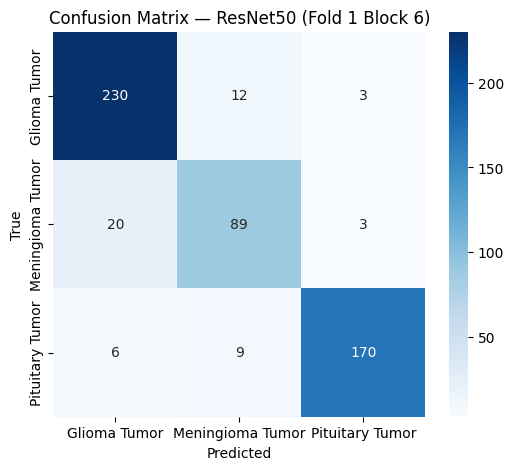

Fold: 1 block 5

Fold: 1 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 14,970,883
Non-trainable params: 8,543,296
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.1374 - accuracy: 0.8434 | val_loss: 0.1275 - val_accuracy: 0.8413
val_accuracy improved from 0.0000 to 0.8413, saving weights to /kaggle/working/ResNet50_block_5_fold_1.pth


Epoch 2/50 | loss: 0.1074 - accuracy: 0.8791 | val_loss: 0.1012 - val_accuracy: 0.8875
val_accuracy improved from 0.8413 to 0.8875, saving weights to /kaggle/working/ResNet50_block_5_fold_1.pth


Epoch 3/50 | loss: 0.0811 - accuracy: 0.9033 | val_loss: 0.0790 - val_accuracy: 0.9041
val_accuracy improved from 0.8875 to 0.9041, saving weights to /kaggle/working/ResNet50_block_5_fold_1.pth


Epoch 4/50 | loss: 0.0749 - accuracy: 0.9064 | val_loss: 0.0573 - val_accuracy: 0.9446
val_accuracy improved from 0.9041 to 0.9446, saving weights to /kaggle/working/ResNet50_block_5_fold_1.pth


...

Epoch 6/50 | loss: 0.0618 - accuracy: 0.9326 | val_loss: 0.1367 - val_accuracy: 0.8395
val_accuracy did not improve from 0.9446


Epoch 7/50 | loss: 0.0599 - accuracy: 0.9290 | val_loss: 0.0737 - val_accuracy: 0.9077
val_accuracy did not improve from 0.9446


Epoch 8/50 | loss: 0.0402 - accuracy: 0.9489 | val_loss: 0.0502 - val_accuracy: 0.9446
val_accuracy did not improve from 0.9446


Epoch 9/50 | loss: 0.0413 - accuracy: 0.9477 | val_loss: 0.0650 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9446


Epoch 10/50 | loss: 0.0385 - accuracy: 0.9441 | val_loss: 0.0685 - val_accuracy: 0.9207
val_accuracy did not improve from 0.9446
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.057263  0.944649
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.96      0.96       245
Meningioma Tumor       0.88      0.88      0.88       112
 Pituitary Tumor       0.96      0.96      0.96       185

        accuracy                           0.94       542
       macro avg       0.94      0.94      0.94       542
    weighted avg       0.94      0.94      0.94       542



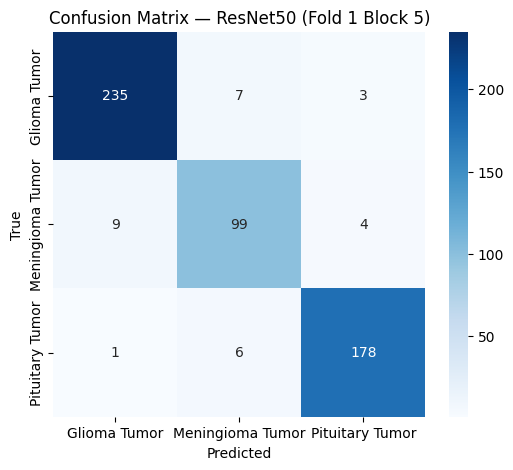

Fold: 1 block 4

Fold: 1 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 22,069,251
Non-trainable params: 1,444,928
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0632 - accuracy: 0.9231 | val_loss: 0.0471 - val_accuracy: 0.9594
val_accuracy improved from 0.0000 to 0.9594, saving weights to /kaggle/working/ResNet50_block_4_fold_1.pth


Epoch 2/50 | loss: 0.0540 - accuracy: 0.9354 | val_loss: 0.0587 - val_accuracy: 0.9354
val_accuracy did not improve from 0.9594


Epoch 3/50 | loss: 0.0422 - accuracy: 0.9489 | val_loss: 0.0552 - val_accuracy: 0.9373
val_accuracy did not improve from 0.9594


Epoch 4/50 | loss: 0.0454 - accuracy: 0.9481 | val_loss: 0.0578 - val_accuracy: 0.9225
val_accuracy did not improve from 0.9594


Epoch 5/50 | loss: 0.0398 - accuracy: 0.9473 | val_loss: 0.0548 - val_accuracy: 0.9391
val_accuracy did not improve from 0.9594


Epoch 6/50 | loss: 0.0215 - accuracy: 0.9730 | val_loss: 0.0356 - val_accuracy: 0.9594
val_accuracy did not improve from 0.9594


Epoch 7/50 | loss: 0.0197 - accuracy: 0.9699 | val_loss: 0.0428 - val_accuracy: 0.9428
val_accuracy did not improve from 0.9594
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.047058   0.95941
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.97      0.97       245
Meningioma Tumor       0.90      0.94      0.92       112
 Pituitary Tumor       0.98      0.96      0.97       185

        accuracy                           0.96       542
       macro avg       0.95      0.96      0.95       542
    weighted avg       0.96      0.96      0.96       542



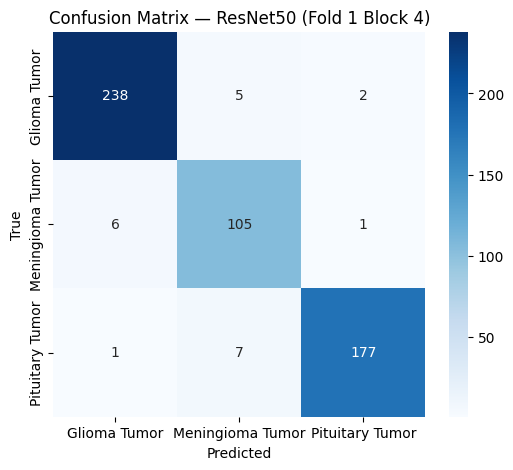

Fold: 1 block 3

Fold: 1 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,288,835
Non-trainable params: 225,344
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0599 - accuracy: 0.9270 | val_loss: 0.0616 - val_accuracy: 0.9373
val_accuracy improved from 0.0000 to 0.9373, saving weights to /kaggle/working/ResNet50_block_3_fold_1.pth


Epoch 2/50 | loss: 0.0446 - accuracy: 0.9437 | val_loss: 0.0802 - val_accuracy: 0.9133
val_accuracy did not improve from 0.9373


Epoch 3/50 | loss: 0.0350 - accuracy: 0.9580 | val_loss: 0.0351 - val_accuracy: 0.9686
val_accuracy improved from 0.9373 to 0.9686, saving weights to /kaggle/working/ResNet50_block_3_fold_1.pth


Epoch 4/50 | loss: 0.0408 - accuracy: 0.9500 | val_loss: 0.0320 - val_accuracy: 0.9686
val_accuracy did not improve from 0.9686


...

Epoch 7/50 | loss: 0.0312 - accuracy: 0.9619 | val_loss: 0.1962 - val_accuracy: 0.8229
val_accuracy did not improve from 0.9742


Epoch 8/50 | loss: 0.0262 - accuracy: 0.9691 | val_loss: 0.0282 - val_accuracy: 0.9668
val_accuracy did not improve from 0.9742


Epoch 9/50 | loss: 0.0183 - accuracy: 0.9778 | val_loss: 0.0476 - val_accuracy: 0.9539
val_accuracy did not improve from 0.9742


Epoch 10/50 | loss: 0.0134 - accuracy: 0.9822 | val_loss: 0.0457 - val_accuracy: 0.9539
val_accuracy did not improve from 0.9742


Epoch 11/50 | loss: 0.0091 - accuracy: 0.9865 | val_loss: 0.0286 - val_accuracy: 0.9723
val_accuracy did not improve from 0.9742
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.031088   0.97417
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.98      0.98       245
Meningioma Tumor       0.92      0.97      0.94       112
 Pituitary Tumor       0.99      0.97      0.98       185

        accuracy                           0.97       542
       macro avg       0.97      0.97      0.97       542
    weighted avg       0.98      0.97      0.97       542



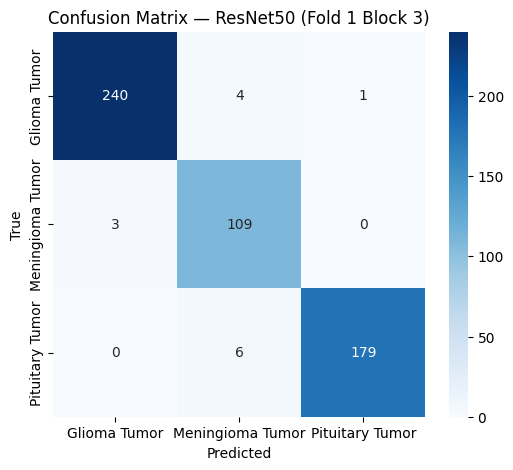

Fold: 1 block 2

Fold: 1 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,504,643
Non-trainable params: 9,536
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backwar

Epoch 1/50 | loss: 0.0264 - accuracy: 0.9663 | val_loss: 0.0437 - val_accuracy: 0.9557
val_accuracy improved from 0.0000 to 0.9557, saving weights to /kaggle/working/ResNet50_block_2_fold_1.pth


Epoch 2/50 | loss: 0.0240 - accuracy: 0.9726 | val_loss: 0.0378 - val_accuracy: 0.9576
val_accuracy improved from 0.9557 to 0.9576, saving weights to /kaggle/working/ResNet50_block_2_fold_1.pth


Epoch 3/50 | loss: 0.0269 - accuracy: 0.9647 | val_loss: 0.0353 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9576


Epoch 4/50 | loss: 0.0135 - accuracy: 0.9794 | val_loss: 0.0577 - val_accuracy: 0.9446
val_accuracy did not improve from 0.9576


...

Epoch 13/50 | loss: 0.0086 - accuracy: 0.9889 | val_loss: 0.0414 - val_accuracy: 0.9557
val_accuracy did not improve from 0.9815


Epoch 14/50 | loss: 0.0064 - accuracy: 0.9929 | val_loss: 0.0306 - val_accuracy: 0.9613
val_accuracy did not improve from 0.9815


Epoch 15/50 | loss: 0.0033 - accuracy: 0.9948 | val_loss: 0.0255 - val_accuracy: 0.9797
val_accuracy did not improve from 0.9815


Epoch 16/50 | loss: 0.0016 - accuracy: 0.9988 | val_loss: 0.0267 - val_accuracy: 0.9760
val_accuracy did not improve from 0.9815


Epoch 17/50 | loss: 0.0020 - accuracy: 0.9976 | val_loss: 0.0250 - val_accuracy: 0.9779
val_accuracy did not improve from 0.9815
early stopping, restoring model weights from the end of the best epoch
      Model     Loss  Accuracy
0  ResNet50  0.02345   0.98155
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.98      0.98       245
Meningioma Tumor       0.96      0.96      0.96       112
 Pituitary Tumor       0.99      0.99      0.99       185

        accuracy                           0.98       542
       macro avg       0.98      0.98      0.98       542
    weighted avg       0.98      0.98      0.98       542



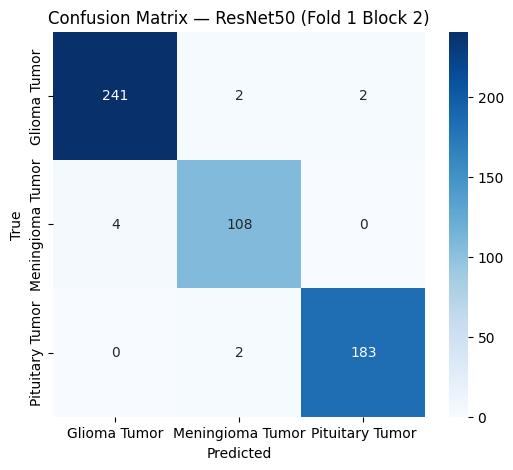

Fold: 1 block 1

Fold: 1 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,514,179
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0091 - accuracy: 0.9881 | val_loss: 0.0346 - val_accuracy: 0.9742
val_accuracy improved from 0.0000 to 0.9742, saving weights to /kaggle/working/ResNet50_block_1_fold_1.pth


Epoch 2/50 | loss: 0.0117 - accuracy: 0.9845 | val_loss: 0.0662 - val_accuracy: 0.9262
val_accuracy did not improve from 0.9742


Epoch 3/50 | loss: 0.0096 - accuracy: 0.9909 | val_loss: 0.0293 - val_accuracy: 0.9686
val_accuracy did not improve from 0.9742


Epoch 4/50 | loss: 0.0068 - accuracy: 0.9905 | val_loss: 0.0220 - val_accuracy: 0.9815
val_accuracy improved from 0.9742 to 0.9815, saving weights to /kaggle/working/ResNet50_block_1_fold_1.pth


...

Epoch 6/50 | loss: 0.0042 - accuracy: 0.9956 | val_loss: 0.0466 - val_accuracy: 0.9631
val_accuracy did not improve from 0.9815


Epoch 7/50 | loss: 0.0037 - accuracy: 0.9956 | val_loss: 0.0277 - val_accuracy: 0.9705
val_accuracy did not improve from 0.9815


Epoch 8/50 | loss: 0.0110 - accuracy: 0.9873 | val_loss: 0.0365 - val_accuracy: 0.9483
val_accuracy did not improve from 0.9815


Epoch 9/50 | loss: 0.0028 - accuracy: 0.9976 | val_loss: 0.0243 - val_accuracy: 0.9723
val_accuracy did not improve from 0.9815


Epoch 10/50 | loss: 0.0017 - accuracy: 0.9980 | val_loss: 0.0240 - val_accuracy: 0.9779
val_accuracy did not improve from 0.9815
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.022048   0.98155
                  precision    recall  f1-score   support

    Glioma Tumor       0.99      0.98      0.99       245
Meningioma Tumor       0.95      0.98      0.96       112
 Pituitary Tumor       0.99      0.98      0.98       185

        accuracy                           0.98       542
       macro avg       0.98      0.98      0.98       542
    weighted avg       0.98      0.98      0.98       542



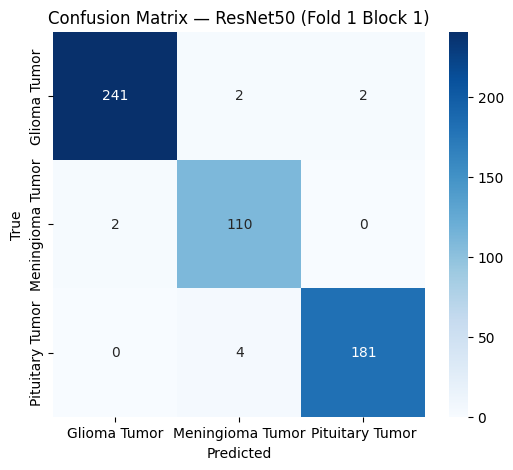

Fold: 2 block 6

Fold: 2 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     (23,508,032)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 6,147
Non-trainable params: 23,508,032
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.4479 - accuracy: 0.5082 | val_loss: 0.3340 - val_accuracy: 0.6627
val_accuracy improved from 0.0000 to 0.6627, saving weights to /kaggle/working/ResNet50_block_6_fold_2.pth


Epoch 2/50 | loss: 0.3271 - accuracy: 0.6637 | val_loss: 0.2837 - val_accuracy: 0.7069
val_accuracy improved from 0.6627 to 0.7069, saving weights to /kaggle/working/ResNet50_block_6_fold_2.pth


Epoch 3/50 | loss: 0.2701 - accuracy: 0.7430 | val_loss: 0.2705 - val_accuracy: 0.6937
val_accuracy did not improve from 0.7069


Epoch 4/50 | loss: 0.2496 - accuracy: 0.7400 | val_loss: 0.2458 - val_accuracy: 0.7275
val_accuracy improved from 0.7069 to 0.7275, saving weights to /kaggle/working/ResNet50_block_6_fold_2.pth


...

Epoch 13/50 | loss: 0.1710 - accuracy: 0.8155 | val_loss: 0.2186 - val_accuracy: 0.7482
val_accuracy did not improve from 0.7732


Epoch 14/50 | loss: 0.1714 - accuracy: 0.8260 | val_loss: 0.2015 - val_accuracy: 0.7673
val_accuracy did not improve from 0.7732


Epoch 15/50 | loss: 0.1633 - accuracy: 0.8340 | val_loss: 0.2007 - val_accuracy: 0.7644
val_accuracy did not improve from 0.7732


Epoch 16/50 | loss: 0.1638 - accuracy: 0.8289 | val_loss: 0.2056 - val_accuracy: 0.7570
val_accuracy did not improve from 0.7732


Epoch 17/50 | loss: 0.1625 - accuracy: 0.8323 | val_loss: 0.1942 - val_accuracy: 0.7658
val_accuracy did not improve from 0.7732
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.201813  0.773196
                  precision    recall  f1-score   support

    Glioma Tumor       0.80      0.88      0.84       338
Meningioma Tumor       0.63      0.48      0.55       167
 Pituitary Tumor       0.82      0.84      0.83       174

        accuracy                           0.77       679
       macro avg       0.75      0.74      0.74       679
    weighted avg       0.76      0.77      0.76       679



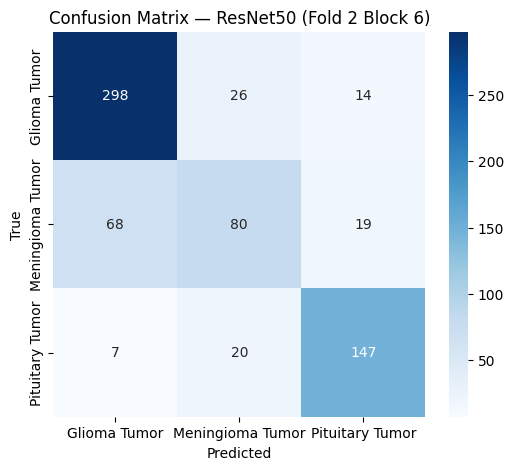

Fold: 2 block 5

Fold: 2 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 14,970,883
Non-trainable params: 8,543,296
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.1467 - accuracy: 0.8449 | val_loss: 0.1430 - val_accuracy: 0.8321
val_accuracy improved from 0.0000 to 0.8321, saving weights to /kaggle/working/ResNet50_block_5_fold_2.pth


Epoch 2/50 | loss: 0.1056 - accuracy: 0.8864 | val_loss: 0.1333 - val_accuracy: 0.8351
val_accuracy improved from 0.8321 to 0.8351, saving weights to /kaggle/working/ResNet50_block_5_fold_2.pth


Epoch 3/50 | loss: 0.0876 - accuracy: 0.9006 | val_loss: 0.2123 - val_accuracy: 0.7850
val_accuracy did not improve from 0.8351


Epoch 4/50 | loss: 0.0710 - accuracy: 0.9195 | val_loss: 0.1230 - val_accuracy: 0.8586
val_accuracy improved from 0.8351 to 0.8586, saving weights to /kaggle/working/ResNet50_block_5_fold_2.pth


...

Epoch 13/50 | loss: 0.0238 - accuracy: 0.9681 | val_loss: 0.1257 - val_accuracy: 0.8763
val_accuracy did not improve from 0.8881


Epoch 14/50 | loss: 0.0256 - accuracy: 0.9723 | val_loss: 0.1212 - val_accuracy: 0.8748
val_accuracy did not improve from 0.8881


Epoch 15/50 | loss: 0.0240 - accuracy: 0.9706 | val_loss: 0.1223 - val_accuracy: 0.8733
val_accuracy did not improve from 0.8881


Epoch 16/50 | loss: 0.0214 - accuracy: 0.9740 | val_loss: 0.1214 - val_accuracy: 0.8837
val_accuracy did not improve from 0.8881


Epoch 17/50 | loss: 0.0215 - accuracy: 0.9706 | val_loss: 0.1220 - val_accuracy: 0.8778
val_accuracy did not improve from 0.8881
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.116562  0.888071
                  precision    recall  f1-score   support

    Glioma Tumor       0.88      0.93      0.91       338
Meningioma Tumor       0.82      0.77      0.79       167
 Pituitary Tumor       0.98      0.92      0.95       174

        accuracy                           0.89       679
       macro avg       0.89      0.87      0.88       679
    weighted avg       0.89      0.89      0.89       679



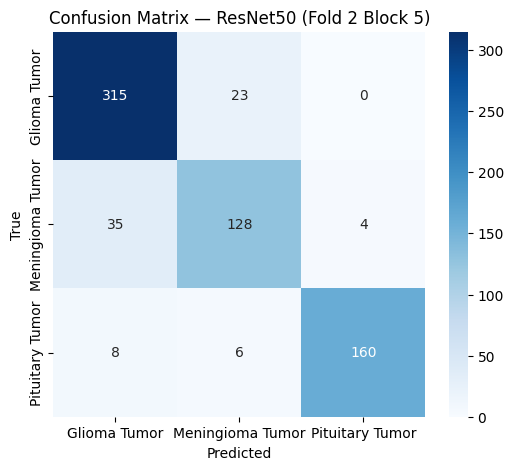

Fold: 2 block 4

Fold: 2 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 22,069,251
Non-trainable params: 1,444,928
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0401 - accuracy: 0.9480 | val_loss: 0.1033 - val_accuracy: 0.8910
val_accuracy improved from 0.0000 to 0.8910, saving weights to /kaggle/working/ResNet50_block_4_fold_2.pth


Epoch 2/50 | loss: 0.0278 - accuracy: 0.9644 | val_loss: 0.1002 - val_accuracy: 0.8940
val_accuracy improved from 0.8910 to 0.8940, saving weights to /kaggle/working/ResNet50_block_4_fold_2.pth


Epoch 3/50 | loss: 0.0312 - accuracy: 0.9610 | val_loss: 0.1425 - val_accuracy: 0.8866
val_accuracy did not improve from 0.8940


Epoch 4/50 | loss: 0.0260 - accuracy: 0.9719 | val_loss: 0.0874 - val_accuracy: 0.8940
val_accuracy did not improve from 0.8940


...

Epoch 11/50 | loss: 0.0071 - accuracy: 0.9908 | val_loss: 0.1119 - val_accuracy: 0.9102
val_accuracy did not improve from 0.9102


Epoch 12/50 | loss: 0.0065 - accuracy: 0.9937 | val_loss: 0.1113 - val_accuracy: 0.9102
val_accuracy did not improve from 0.9102


Epoch 13/50 | loss: 0.0050 - accuracy: 0.9950 | val_loss: 0.1182 - val_accuracy: 0.9057
val_accuracy did not improve from 0.9102


Epoch 14/50 | loss: 0.0051 - accuracy: 0.9945 | val_loss: 0.1173 - val_accuracy: 0.9072
val_accuracy did not improve from 0.9102


Epoch 15/50 | loss: 0.0047 - accuracy: 0.9941 | val_loss: 0.1200 - val_accuracy: 0.9072
val_accuracy did not improve from 0.9102
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.099633  0.910162
                  precision    recall  f1-score   support

    Glioma Tumor       0.92      0.93      0.92       338
Meningioma Tumor       0.83      0.87      0.85       167
 Pituitary Tumor       0.99      0.91      0.95       174

        accuracy                           0.91       679
       macro avg       0.91      0.90      0.91       679
    weighted avg       0.91      0.91      0.91       679



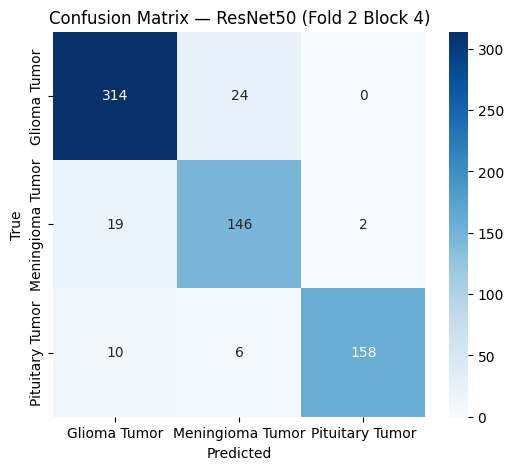

Fold: 2 block 3

Fold: 2 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,288,835
Non-trainable params: 225,344
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0162 - accuracy: 0.9790 | val_loss: 0.1029 - val_accuracy: 0.9278
val_accuracy improved from 0.0000 to 0.9278, saving weights to /kaggle/working/ResNet50_block_3_fold_2.pth


Epoch 2/50 | loss: 0.0174 - accuracy: 0.9807 | val_loss: 0.1237 - val_accuracy: 0.8999
val_accuracy did not improve from 0.9278


Epoch 3/50 | loss: 0.0105 - accuracy: 0.9883 | val_loss: 0.1060 - val_accuracy: 0.9234
val_accuracy did not improve from 0.9278


Epoch 4/50 | loss: 0.0216 - accuracy: 0.9744 | val_loss: 0.1021 - val_accuracy: 0.9028
val_accuracy did not improve from 0.9278


...

Epoch 11/50 | loss: 0.0065 - accuracy: 0.9925 | val_loss: 0.1225 - val_accuracy: 0.9205
val_accuracy did not improve from 0.9440


Epoch 12/50 | loss: 0.0056 - accuracy: 0.9933 | val_loss: 0.1404 - val_accuracy: 0.9234
val_accuracy did not improve from 0.9440


Epoch 13/50 | loss: 0.0053 - accuracy: 0.9937 | val_loss: 0.1031 - val_accuracy: 0.9396
val_accuracy did not improve from 0.9440


Epoch 14/50 | loss: 0.0018 - accuracy: 0.9971 | val_loss: 0.1150 - val_accuracy: 0.9323
val_accuracy did not improve from 0.9440


Epoch 15/50 | loss: 0.0013 - accuracy: 0.9992 | val_loss: 0.1199 - val_accuracy: 0.9308
val_accuracy did not improve from 0.9440
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.073498  0.944035
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.96      0.96       338
Meningioma Tumor       0.92      0.87      0.90       167
 Pituitary Tumor       0.95      0.97      0.96       174

        accuracy                           0.94       679
       macro avg       0.94      0.94      0.94       679
    weighted avg       0.94      0.94      0.94       679



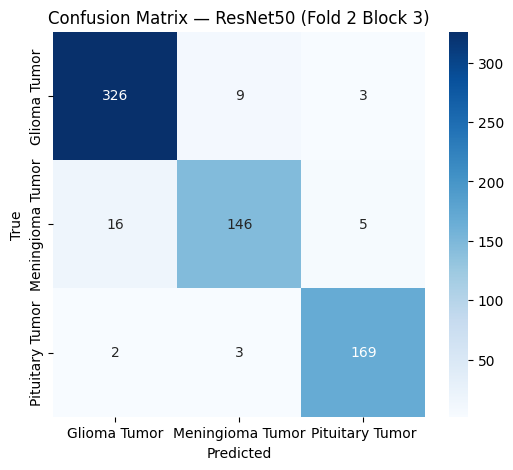

Fold: 2 block 2

Fold: 2 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,504,643
Non-trainable params: 9,536
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backwar

Epoch 1/50 | loss: 0.0145 - accuracy: 0.9820 | val_loss: 0.0919 - val_accuracy: 0.9249
val_accuracy improved from 0.0000 to 0.9249, saving weights to /kaggle/working/ResNet50_block_2_fold_2.pth


Epoch 2/50 | loss: 0.0060 - accuracy: 0.9925 | val_loss: 0.1510 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9249


Epoch 3/50 | loss: 0.0042 - accuracy: 0.9950 | val_loss: 0.1605 - val_accuracy: 0.9102
val_accuracy did not improve from 0.9249


Epoch 4/50 | loss: 0.0067 - accuracy: 0.9925 | val_loss: 0.1372 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9249


...

Epoch 9/50 | loss: 0.0054 - accuracy: 0.9937 | val_loss: 0.1112 - val_accuracy: 0.9337
val_accuracy did not improve from 0.9455


Epoch 10/50 | loss: 0.0018 - accuracy: 0.9979 | val_loss: 0.1111 - val_accuracy: 0.9367
val_accuracy did not improve from 0.9455


Epoch 11/50 | loss: 0.0016 - accuracy: 0.9975 | val_loss: 0.1465 - val_accuracy: 0.9278
val_accuracy did not improve from 0.9455


Epoch 12/50 | loss: 0.0014 - accuracy: 0.9979 | val_loss: 0.1101 - val_accuracy: 0.9381
val_accuracy did not improve from 0.9455


Epoch 13/50 | loss: 0.0003 - accuracy: 1.0000 | val_loss: 0.1185 - val_accuracy: 0.9352
val_accuracy did not improve from 0.9455
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.083357  0.945508
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.93      0.95       338
Meningioma Tumor       0.86      0.94      0.90       167
 Pituitary Tumor       0.98      0.98      0.98       174

        accuracy                           0.95       679
       macro avg       0.94      0.95      0.94       679
    weighted avg       0.95      0.95      0.95       679



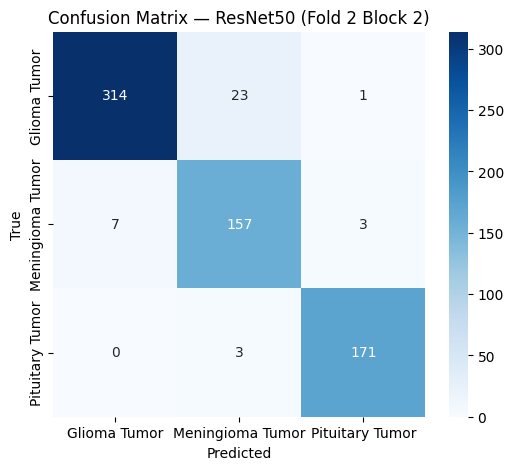

Fold: 2 block 1

Fold: 2 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,514,179
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0084 - accuracy: 0.9912 | val_loss: 0.1298 - val_accuracy: 0.9278
val_accuracy improved from 0.0000 to 0.9278, saving weights to /kaggle/working/ResNet50_block_1_fold_2.pth


Epoch 2/50 | loss: 0.0118 - accuracy: 0.9883 | val_loss: 0.0785 - val_accuracy: 0.9440
val_accuracy improved from 0.9278 to 0.9440, saving weights to /kaggle/working/ResNet50_block_1_fold_2.pth


Epoch 3/50 | loss: 0.0059 - accuracy: 0.9945 | val_loss: 0.1109 - val_accuracy: 0.9264
val_accuracy did not improve from 0.9440


Epoch 4/50 | loss: 0.0043 - accuracy: 0.9941 | val_loss: 0.1123 - val_accuracy: 0.9308
val_accuracy did not improve from 0.9440


Epoch 5/50 | loss: 0.0038 - accuracy: 0.9945 | val_loss: 0.1073 - val_accuracy: 0.9337
val_accuracy did not improve from 0.9440


Epoch 6/50 | loss: 0.0007 - accuracy: 0.9992 | val_loss: 0.1572 - val_accuracy: 0.9219
val_accuracy did not improve from 0.9440


Epoch 7/50 | loss: 0.0015 - accuracy: 0.9983 | val_loss: 0.1516 - val_accuracy: 0.9190
val_accuracy did not improve from 0.9440


Epoch 8/50 | loss: 0.0010 - accuracy: 0.9992 | val_loss: 0.1235 - val_accuracy: 0.9323
val_accuracy did not improve from 0.9440
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.078509  0.944035
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.94      0.95       338
Meningioma Tumor       0.88      0.94      0.91       167
 Pituitary Tumor       0.97      0.96      0.96       174

        accuracy                           0.94       679
       macro avg       0.94      0.95      0.94       679
    weighted avg       0.95      0.94      0.94       679



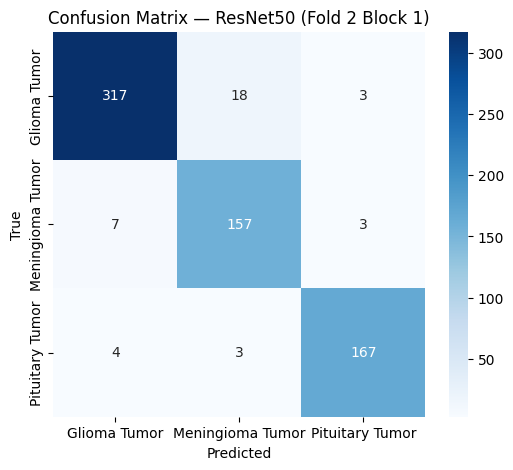

Fold: 3 block 6

Fold: 3 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     (23,508,032)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 6,147
Non-trainable params: 23,508,032
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.4412 - accuracy: 0.5249 | val_loss: 0.3723 - val_accuracy: 0.6381
val_accuracy improved from 0.0000 to 0.6381, saving weights to /kaggle/working/ResNet50_block_6_fold_3.pth


Epoch 2/50 | loss: 0.3242 - accuracy: 0.6746 | val_loss: 0.3037 - val_accuracy: 0.7168
val_accuracy improved from 0.6381 to 0.7168, saving weights to /kaggle/working/ResNet50_block_6_fold_3.pth


Epoch 3/50 | loss: 0.2694 - accuracy: 0.7267 | val_loss: 0.2713 - val_accuracy: 0.7343
val_accuracy improved from 0.7168 to 0.7343, saving weights to /kaggle/working/ResNet50_block_6_fold_3.pth


Epoch 4/50 | loss: 0.2462 - accuracy: 0.7588 | val_loss: 0.2478 - val_accuracy: 0.7640
val_accuracy improved from 0.7343 to 0.7640, saving weights to /kaggle/working/ResNet50_block_6_fold_3.pth


...

Epoch 27/50 | loss: 0.1476 - accuracy: 0.8395 | val_loss: 0.1716 - val_accuracy: 0.8147
val_accuracy did not improve from 0.8304


Epoch 28/50 | loss: 0.1436 - accuracy: 0.8479 | val_loss: 0.1766 - val_accuracy: 0.7990
val_accuracy did not improve from 0.8304


Epoch 29/50 | loss: 0.1548 - accuracy: 0.8315 | val_loss: 0.1648 - val_accuracy: 0.8269
val_accuracy did not improve from 0.8304


Epoch 30/50 | loss: 0.1411 - accuracy: 0.8503 | val_loss: 0.1681 - val_accuracy: 0.8217
val_accuracy did not improve from 0.8304


Epoch 31/50 | loss: 0.1460 - accuracy: 0.8411 | val_loss: 0.1716 - val_accuracy: 0.8129
val_accuracy did not improve from 0.8304
early stopping, restoring model weights from the end of the best epoch
      Model     Loss  Accuracy
0  ResNet50  0.16676   0.83042
                  precision    recall  f1-score   support

    Glioma Tumor       0.85      0.84      0.84       231
Meningioma Tumor       0.70      0.69      0.69       139
 Pituitary Tumor       0.89      0.92      0.91       202

        accuracy                           0.83       572
       macro avg       0.81      0.82      0.82       572
    weighted avg       0.83      0.83      0.83       572



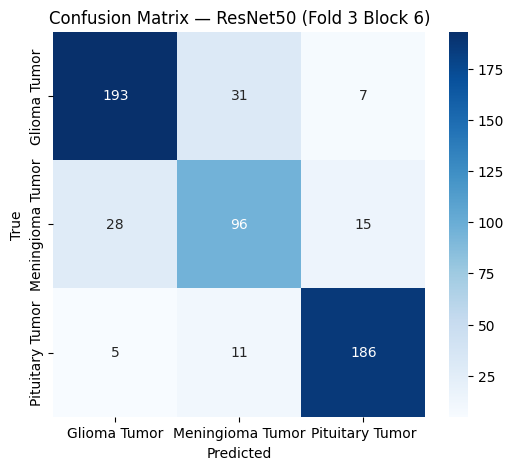

Fold: 3 block 5

Fold: 3 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 14,970,883
Non-trainable params: 8,543,296
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.1384 - accuracy: 0.8499 | val_loss: 0.1415 - val_accuracy: 0.8304
val_accuracy improved from 0.0000 to 0.8304, saving weights to /kaggle/working/ResNet50_block_5_fold_3.pth


Epoch 2/50 | loss: 0.0976 - accuracy: 0.8876 | val_loss: 0.1146 - val_accuracy: 0.8689
val_accuracy improved from 0.8304 to 0.8689, saving weights to /kaggle/working/ResNet50_block_5_fold_3.pth


Epoch 3/50 | loss: 0.0768 - accuracy: 0.9101 | val_loss: 0.1115 - val_accuracy: 0.8689
val_accuracy did not improve from 0.8689


Epoch 4/50 | loss: 0.0663 - accuracy: 0.9209 | val_loss: 0.1105 - val_accuracy: 0.8601
val_accuracy did not improve from 0.8689


...

Epoch 11/50 | loss: 0.0302 - accuracy: 0.9663 | val_loss: 0.1003 - val_accuracy: 0.8654
val_accuracy did not improve from 0.9038


Epoch 12/50 | loss: 0.0297 - accuracy: 0.9647 | val_loss: 0.1054 - val_accuracy: 0.8951
val_accuracy did not improve from 0.9038


Epoch 13/50 | loss: 0.0313 - accuracy: 0.9591 | val_loss: 0.0878 - val_accuracy: 0.8899
val_accuracy did not improve from 0.9038


Epoch 14/50 | loss: 0.0195 - accuracy: 0.9763 | val_loss: 0.0925 - val_accuracy: 0.8899
val_accuracy did not improve from 0.9038


Epoch 15/50 | loss: 0.0163 - accuracy: 0.9787 | val_loss: 0.1155 - val_accuracy: 0.8916
val_accuracy did not improve from 0.9038
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.101668  0.903846
                  precision    recall  f1-score   support

    Glioma Tumor       0.90      0.90      0.90       231
Meningioma Tumor       0.83      0.80      0.82       139
 Pituitary Tumor       0.95      0.99      0.97       202

        accuracy                           0.90       572
       macro avg       0.90      0.89      0.89       572
    weighted avg       0.90      0.90      0.90       572



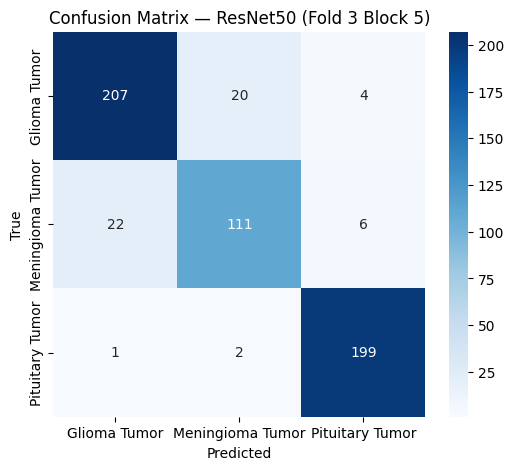

Fold: 3 block 4

Fold: 3 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 22,069,251
Non-trainable params: 1,444,928
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0427 - accuracy: 0.9490 | val_loss: 0.0953 - val_accuracy: 0.8899
val_accuracy improved from 0.0000 to 0.8899, saving weights to /kaggle/working/ResNet50_block_4_fold_3.pth


Epoch 2/50 | loss: 0.0294 - accuracy: 0.9635 | val_loss: 0.1051 - val_accuracy: 0.8881
val_accuracy did not improve from 0.8899


Epoch 3/50 | loss: 0.0238 - accuracy: 0.9707 | val_loss: 0.0897 - val_accuracy: 0.9073
val_accuracy improved from 0.8899 to 0.9073, saving weights to /kaggle/working/ResNet50_block_4_fold_3.pth


Epoch 4/50 | loss: 0.0239 - accuracy: 0.9723 | val_loss: 0.1077 - val_accuracy: 0.9108
val_accuracy improved from 0.9073 to 0.9108, saving weights to /kaggle/working/ResNet50_block_4_fold_3.pth


...

Epoch 14/50 | loss: 0.0068 - accuracy: 0.9912 | val_loss: 0.1057 - val_accuracy: 0.9126
val_accuracy did not improve from 0.9178


Epoch 15/50 | loss: 0.0067 - accuracy: 0.9936 | val_loss: 0.1033 - val_accuracy: 0.9143
val_accuracy did not improve from 0.9178


Epoch 16/50 | loss: 0.0060 - accuracy: 0.9920 | val_loss: 0.1028 - val_accuracy: 0.9143
val_accuracy did not improve from 0.9178


Epoch 17/50 | loss: 0.0065 - accuracy: 0.9920 | val_loss: 0.1023 - val_accuracy: 0.9143
val_accuracy did not improve from 0.9178


Epoch 18/50 | loss: 0.0064 - accuracy: 0.9928 | val_loss: 0.1034 - val_accuracy: 0.9143
val_accuracy did not improve from 0.9178
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.103825  0.917832
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.88      0.91       231
Meningioma Tumor       0.82      0.87      0.84       139
 Pituitary Tumor       0.97      0.99      0.98       202

        accuracy                           0.92       572
       macro avg       0.91      0.91      0.91       572
    weighted avg       0.92      0.92      0.92       572



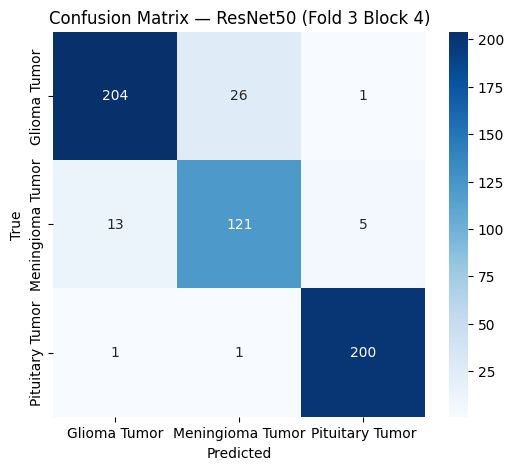

Fold: 3 block 3

Fold: 3 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,288,835
Non-trainable params: 225,344
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0179 - accuracy: 0.9795 | val_loss: 0.1007 - val_accuracy: 0.9126
val_accuracy improved from 0.0000 to 0.9126, saving weights to /kaggle/working/ResNet50_block_3_fold_3.pth


Epoch 2/50 | loss: 0.0160 - accuracy: 0.9823 | val_loss: 0.0945 - val_accuracy: 0.9126
val_accuracy did not improve from 0.9126


Epoch 3/50 | loss: 0.0129 - accuracy: 0.9839 | val_loss: 0.1373 - val_accuracy: 0.9073
val_accuracy did not improve from 0.9126


Epoch 4/50 | loss: 0.0130 - accuracy: 0.9848 | val_loss: 0.1354 - val_accuracy: 0.8916
val_accuracy did not improve from 0.9126


...

Epoch 11/50 | loss: 0.0025 - accuracy: 0.9972 | val_loss: 0.1134 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9388


Epoch 12/50 | loss: 0.0019 - accuracy: 0.9976 | val_loss: 0.1094 - val_accuracy: 0.9388
val_accuracy did not improve from 0.9388


Epoch 13/50 | loss: 0.0018 - accuracy: 0.9980 | val_loss: 0.1244 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9388


Epoch 14/50 | loss: 0.0016 - accuracy: 0.9984 | val_loss: 0.1145 - val_accuracy: 0.9353
val_accuracy did not improve from 0.9388


Epoch 15/50 | loss: 0.0020 - accuracy: 0.9980 | val_loss: 0.1168 - val_accuracy: 0.9336
val_accuracy did not improve from 0.9388
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.113886  0.938811
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.90      0.93       231
Meningioma Tumor       0.84      0.92      0.88       139
 Pituitary Tumor       0.98      1.00      0.99       202

        accuracy                           0.94       572
       macro avg       0.93      0.94      0.93       572
    weighted avg       0.94      0.94      0.94       572



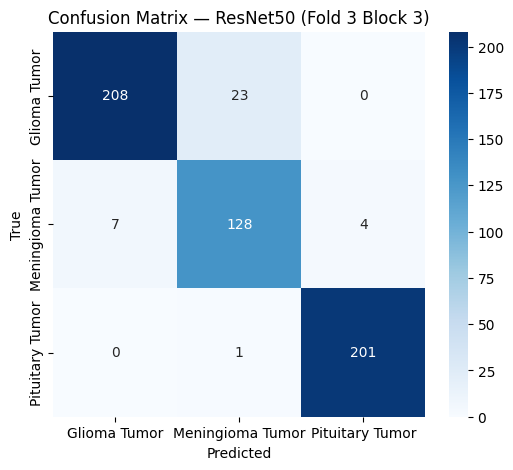

Fold: 3 block 2

Fold: 3 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,504,643
Non-trainable params: 9,536
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backwar

Epoch 1/50 | loss: 0.0145 - accuracy: 0.9823 | val_loss: 0.1389 - val_accuracy: 0.9178
val_accuracy improved from 0.0000 to 0.9178, saving weights to /kaggle/working/ResNet50_block_2_fold_3.pth


Epoch 2/50 | loss: 0.0071 - accuracy: 0.9904 | val_loss: 0.1113 - val_accuracy: 0.9178
val_accuracy did not improve from 0.9178


Epoch 3/50 | loss: 0.0081 - accuracy: 0.9892 | val_loss: 0.1332 - val_accuracy: 0.9196
val_accuracy improved from 0.9178 to 0.9196, saving weights to /kaggle/working/ResNet50_block_2_fold_3.pth


Epoch 4/50 | loss: 0.0082 - accuracy: 0.9920 | val_loss: 0.1022 - val_accuracy: 0.9266
val_accuracy improved from 0.9196 to 0.9266, saving weights to /kaggle/working/ResNet50_block_2_fold_3.pth


...

Epoch 13/50 | loss: 0.0008 - accuracy: 0.9992 | val_loss: 0.0997 - val_accuracy: 0.9388
val_accuracy did not improve from 0.9423


Epoch 14/50 | loss: 0.0013 - accuracy: 0.9988 | val_loss: 0.1004 - val_accuracy: 0.9371
val_accuracy did not improve from 0.9423


Epoch 15/50 | loss: 0.0016 - accuracy: 0.9980 | val_loss: 0.1041 - val_accuracy: 0.9388
val_accuracy did not improve from 0.9423


Epoch 16/50 | loss: 0.0009 - accuracy: 0.9984 | val_loss: 0.1074 - val_accuracy: 0.9371
val_accuracy did not improve from 0.9423


Epoch 17/50 | loss: 0.0006 - accuracy: 1.0000 | val_loss: 0.1057 - val_accuracy: 0.9371
val_accuracy did not improve from 0.9423
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.087645  0.942308
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.94      0.94       231
Meningioma Tumor       0.89      0.88      0.88       139
 Pituitary Tumor       0.97      1.00      0.98       202

        accuracy                           0.94       572
       macro avg       0.94      0.94      0.94       572
    weighted avg       0.94      0.94      0.94       572



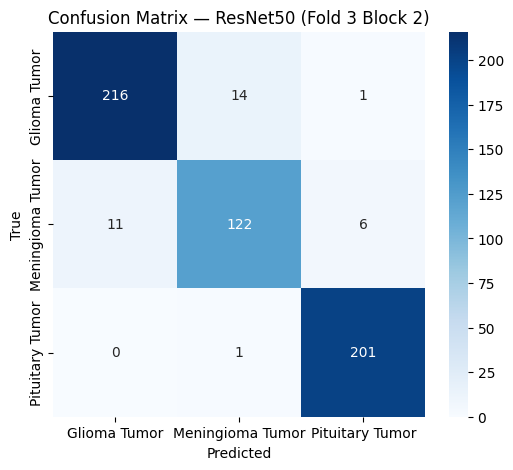

Fold: 3 block 1

Fold: 3 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,514,179
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0094 - accuracy: 0.9876 | val_loss: 0.1057 - val_accuracy: 0.9371
val_accuracy improved from 0.0000 to 0.9371, saving weights to /kaggle/working/ResNet50_block_1_fold_3.pth


Epoch 2/50 | loss: 0.0020 - accuracy: 0.9968 | val_loss: 0.0978 - val_accuracy: 0.9423
val_accuracy improved from 0.9371 to 0.9423, saving weights to /kaggle/working/ResNet50_block_1_fold_3.pth


Epoch 3/50 | loss: 0.0059 - accuracy: 0.9924 | val_loss: 0.1228 - val_accuracy: 0.9248
val_accuracy did not improve from 0.9423


Epoch 4/50 | loss: 0.0039 - accuracy: 0.9976 | val_loss: 0.1292 - val_accuracy: 0.9283
val_accuracy did not improve from 0.9423


...

Epoch 8/50 | loss: 0.0007 - accuracy: 0.9992 | val_loss: 0.1318 - val_accuracy: 0.9388
val_accuracy did not improve from 0.9476


Epoch 9/50 | loss: 0.0007 - accuracy: 0.9988 | val_loss: 0.1317 - val_accuracy: 0.9423
val_accuracy did not improve from 0.9476


Epoch 10/50 | loss: 0.0014 - accuracy: 0.9992 | val_loss: 0.1557 - val_accuracy: 0.9318
val_accuracy did not improve from 0.9476


Epoch 11/50 | loss: 0.0004 - accuracy: 0.9996 | val_loss: 0.1434 - val_accuracy: 0.9353
val_accuracy did not improve from 0.9476


Epoch 12/50 | loss: 0.0003 - accuracy: 1.0000 | val_loss: 0.1338 - val_accuracy: 0.9406
val_accuracy did not improve from 0.9476
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.113237  0.947552
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.94      0.94       231
Meningioma Tumor       0.88      0.91      0.89       139
 Pituitary Tumor       0.99      0.99      0.99       202

        accuracy                           0.95       572
       macro avg       0.94      0.94      0.94       572
    weighted avg       0.95      0.95      0.95       572



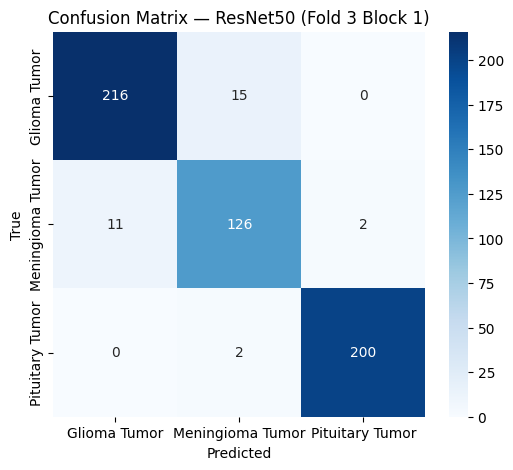

Fold: 4 block 6

Fold: 4 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     (23,508,032)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 6,147
Non-trainable params: 23,508,032
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.4481 - accuracy: 0.5119 | val_loss: 0.3397 - val_accuracy: 0.7070
val_accuracy improved from 0.0000 to 0.7070, saving weights to /kaggle/working/ResNet50_block_6_fold_4.pth


Epoch 2/50 | loss: 0.3315 - accuracy: 0.6601 | val_loss: 0.2771 - val_accuracy: 0.7564
val_accuracy improved from 0.7070 to 0.7564, saving weights to /kaggle/working/ResNet50_block_6_fold_4.pth


Epoch 3/50 | loss: 0.2776 - accuracy: 0.7167 | val_loss: 0.2400 - val_accuracy: 0.7882
val_accuracy improved from 0.7564 to 0.7882, saving weights to /kaggle/working/ResNet50_block_6_fold_4.pth


Epoch 4/50 | loss: 0.2519 - accuracy: 0.7447 | val_loss: 0.2216 - val_accuracy: 0.7914
val_accuracy improved from 0.7882 to 0.7914, saving weights to /kaggle/working/ResNet50_block_6_fold_4.pth


...

Epoch 11/50 | loss: 0.2013 - accuracy: 0.7759 | val_loss: 0.1711 - val_accuracy: 0.8105
val_accuracy did not improve from 0.8344


Epoch 12/50 | loss: 0.1870 - accuracy: 0.7952 | val_loss: 0.1677 - val_accuracy: 0.8089
val_accuracy did not improve from 0.8344


Epoch 13/50 | loss: 0.1915 - accuracy: 0.7984 | val_loss: 0.1624 - val_accuracy: 0.8153
val_accuracy did not improve from 0.8344


Epoch 14/50 | loss: 0.1790 - accuracy: 0.8046 | val_loss: 0.1621 - val_accuracy: 0.8153
val_accuracy did not improve from 0.8344


Epoch 15/50 | loss: 0.1778 - accuracy: 0.8186 | val_loss: 0.1624 - val_accuracy: 0.8121
val_accuracy did not improve from 0.8344
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.173034  0.834395
                  precision    recall  f1-score   support

    Glioma Tumor       0.83      0.95      0.89       325
Meningioma Tumor       0.76      0.48      0.58       124
 Pituitary Tumor       0.87      0.87      0.87       179

        accuracy                           0.83       628
       macro avg       0.82      0.77      0.78       628
    weighted avg       0.83      0.83      0.82       628



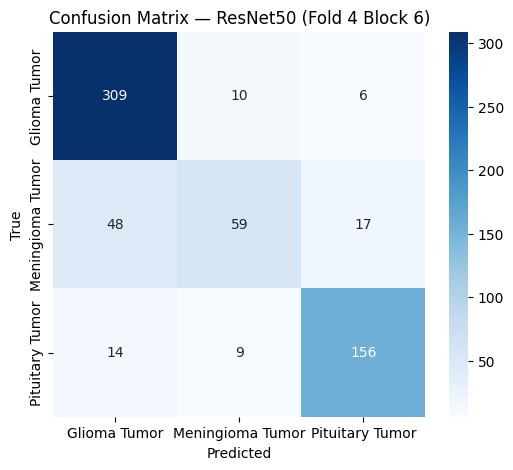

Fold: 4 block 5

Fold: 4 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 14,970,883
Non-trainable params: 8,543,296
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.1621 - accuracy: 0.8153 | val_loss: 0.1069 - val_accuracy: 0.8726
val_accuracy improved from 0.0000 to 0.8726, saving weights to /kaggle/working/ResNet50_block_5_fold_4.pth


Epoch 2/50 | loss: 0.1178 - accuracy: 0.8588 | val_loss: 0.0935 - val_accuracy: 0.8901
val_accuracy improved from 0.8726 to 0.8901, saving weights to /kaggle/working/ResNet50_block_5_fold_4.pth


Epoch 3/50 | loss: 0.1012 - accuracy: 0.8859 | val_loss: 0.0920 - val_accuracy: 0.8933
val_accuracy improved from 0.8901 to 0.8933, saving weights to /kaggle/working/ResNet50_block_5_fold_4.pth


Epoch 4/50 | loss: 0.0823 - accuracy: 0.8990 | val_loss: 0.0908 - val_accuracy: 0.8965
val_accuracy improved from 0.8933 to 0.8965, saving weights to /kaggle/working/ResNet50_block_5_fold_4.pth


...

Epoch 8/50 | loss: 0.0558 - accuracy: 0.9323 | val_loss: 0.0827 - val_accuracy: 0.9172
val_accuracy did not improve from 0.9315


Epoch 9/50 | loss: 0.0443 - accuracy: 0.9392 | val_loss: 0.0752 - val_accuracy: 0.9124
val_accuracy did not improve from 0.9315


Epoch 10/50 | loss: 0.0428 - accuracy: 0.9429 | val_loss: 0.0712 - val_accuracy: 0.9220
val_accuracy did not improve from 0.9315


Epoch 11/50 | loss: 0.0334 - accuracy: 0.9528 | val_loss: 0.0668 - val_accuracy: 0.9299
val_accuracy did not improve from 0.9315


Epoch 12/50 | loss: 0.0299 - accuracy: 0.9647 | val_loss: 0.0670 - val_accuracy: 0.9315
val_accuracy did not improve from 0.9315
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.067821  0.931529
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.93      0.95       325
Meningioma Tumor       0.79      0.92      0.85       124
 Pituitary Tumor       0.97      0.95      0.96       179

        accuracy                           0.93       628
       macro avg       0.91      0.93      0.92       628
    weighted avg       0.94      0.93      0.93       628



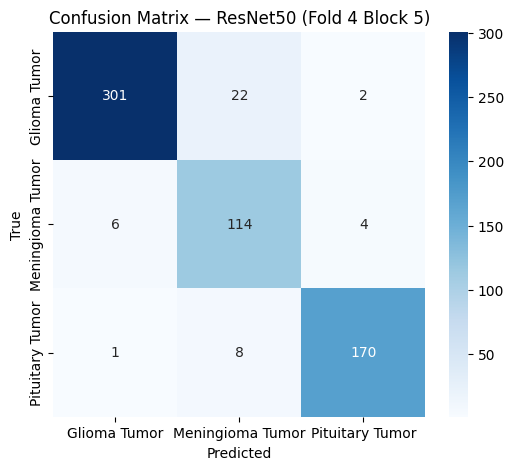

Fold: 4 block 4

Fold: 4 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 22,069,251
Non-trainable params: 1,444,928
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0615 - accuracy: 0.9232 | val_loss: 0.0701 - val_accuracy: 0.9315
val_accuracy improved from 0.0000 to 0.9315, saving weights to /kaggle/working/ResNet50_block_4_fold_4.pth


Epoch 2/50 | loss: 0.0479 - accuracy: 0.9401 | val_loss: 0.1031 - val_accuracy: 0.8949
val_accuracy did not improve from 0.9315


Epoch 3/50 | loss: 0.0403 - accuracy: 0.9491 | val_loss: 0.0670 - val_accuracy: 0.9379
val_accuracy improved from 0.9315 to 0.9379, saving weights to /kaggle/working/ResNet50_block_4_fold_4.pth


Epoch 4/50 | loss: 0.0335 - accuracy: 0.9589 | val_loss: 0.0660 - val_accuracy: 0.9299
val_accuracy did not improve from 0.9379


...

Epoch 15/50 | loss: 0.0054 - accuracy: 0.9922 | val_loss: 0.0605 - val_accuracy: 0.9538
val_accuracy did not improve from 0.9538


Epoch 16/50 | loss: 0.0039 - accuracy: 0.9963 | val_loss: 0.0607 - val_accuracy: 0.9538
val_accuracy did not improve from 0.9538


Epoch 17/50 | loss: 0.0041 - accuracy: 0.9943 | val_loss: 0.0601 - val_accuracy: 0.9538
val_accuracy did not improve from 0.9538


Epoch 18/50 | loss: 0.0052 - accuracy: 0.9947 | val_loss: 0.0619 - val_accuracy: 0.9538
val_accuracy did not improve from 0.9538


Epoch 19/50 | loss: 0.0063 - accuracy: 0.9938 | val_loss: 0.0614 - val_accuracy: 0.9538
val_accuracy did not improve from 0.9538
early stopping, restoring model weights from the end of the best epoch
      Model     Loss  Accuracy
0  ResNet50  0.05852  0.953822
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.98      0.97       325
Meningioma Tumor       0.90      0.88      0.89       124
 Pituitary Tumor       0.98      0.97      0.97       179

        accuracy                           0.95       628
       macro avg       0.95      0.94      0.94       628
    weighted avg       0.95      0.95      0.95       628



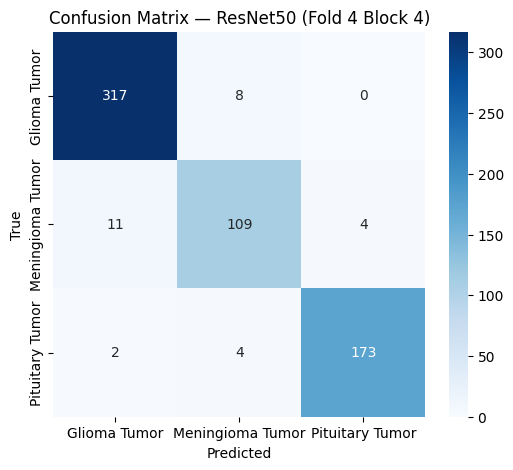

Fold: 4 block 3

Fold: 4 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,288,835
Non-trainable params: 225,344
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0189 - accuracy: 0.9770 | val_loss: 0.0780 - val_accuracy: 0.9379
val_accuracy improved from 0.0000 to 0.9379, saving weights to /kaggle/working/ResNet50_block_3_fold_4.pth


Epoch 2/50 | loss: 0.0138 - accuracy: 0.9852 | val_loss: 0.0523 - val_accuracy: 0.9554
val_accuracy improved from 0.9379 to 0.9554, saving weights to /kaggle/working/ResNet50_block_3_fold_4.pth


Epoch 3/50 | loss: 0.0092 - accuracy: 0.9901 | val_loss: 0.0544 - val_accuracy: 0.9682
val_accuracy improved from 0.9554 to 0.9682, saving weights to /kaggle/working/ResNet50_block_3_fold_4.pth


Epoch 4/50 | loss: 0.0129 - accuracy: 0.9807 | val_loss: 0.0796 - val_accuracy: 0.9299
val_accuracy did not improve from 0.9682


Epoch 5/50 | loss: 0.0170 - accuracy: 0.9770 | val_loss: 0.0662 - val_accuracy: 0.9459
val_accuracy did not improve from 0.9682


Epoch 6/50 | loss: 0.0121 - accuracy: 0.9856 | val_loss: 0.0731 - val_accuracy: 0.9379
val_accuracy did not improve from 0.9682


Epoch 7/50 | loss: 0.0038 - accuracy: 0.9963 | val_loss: 0.0632 - val_accuracy: 0.9538
val_accuracy did not improve from 0.9682


Epoch 8/50 | loss: 0.0040 - accuracy: 0.9963 | val_loss: 0.0669 - val_accuracy: 0.9570
val_accuracy did not improve from 0.9682


Epoch 9/50 | loss: 0.0020 - accuracy: 0.9988 | val_loss: 0.0696 - val_accuracy: 0.9650
val_accuracy did not improve from 0.9682
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.054426  0.968153
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.98      0.98       325
Meningioma Tumor       0.91      0.95      0.93       124
 Pituitary Tumor       0.99      0.96      0.97       179

        accuracy                           0.97       628
       macro avg       0.96      0.96      0.96       628
    weighted avg       0.97      0.97      0.97       628



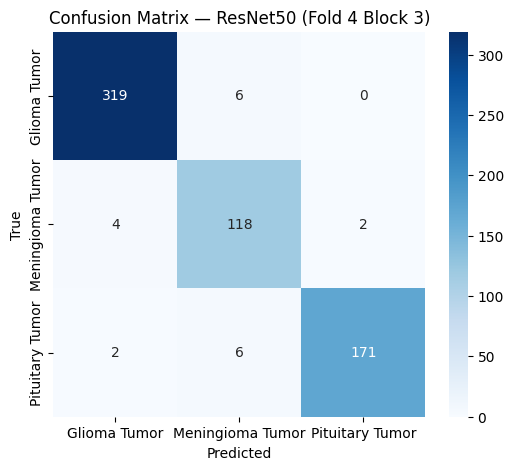

Fold: 4 block 2

Fold: 4 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,504,643
Non-trainable params: 9,536
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backwar

Epoch 1/50 | loss: 0.0179 - accuracy: 0.9762 | val_loss: 0.0786 - val_accuracy: 0.9411
val_accuracy improved from 0.0000 to 0.9411, saving weights to /kaggle/working/ResNet50_block_2_fold_4.pth


Epoch 2/50 | loss: 0.0118 - accuracy: 0.9860 | val_loss: 0.0671 - val_accuracy: 0.9490
val_accuracy improved from 0.9411 to 0.9490, saving weights to /kaggle/working/ResNet50_block_2_fold_4.pth


Epoch 3/50 | loss: 0.0082 - accuracy: 0.9901 | val_loss: 0.0979 - val_accuracy: 0.9395
val_accuracy did not improve from 0.9490


Epoch 4/50 | loss: 0.0123 - accuracy: 0.9877 | val_loss: 0.0704 - val_accuracy: 0.9331
val_accuracy did not improve from 0.9490


...

Epoch 14/50 | loss: 0.0006 - accuracy: 1.0000 | val_loss: 0.0745 - val_accuracy: 0.9618
val_accuracy did not improve from 0.9650


Epoch 15/50 | loss: 0.0014 - accuracy: 0.9988 | val_loss: 0.0729 - val_accuracy: 0.9602
val_accuracy did not improve from 0.9650


Epoch 16/50 | loss: 0.0017 - accuracy: 0.9979 | val_loss: 0.0766 - val_accuracy: 0.9586
val_accuracy did not improve from 0.9650


Epoch 17/50 | loss: 0.0011 - accuracy: 0.9996 | val_loss: 0.0759 - val_accuracy: 0.9602
val_accuracy did not improve from 0.9650


Epoch 18/50 | loss: 0.0008 - accuracy: 0.9996 | val_loss: 0.0768 - val_accuracy: 0.9602
val_accuracy did not improve from 0.9650
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.069712  0.964968
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.99      0.98       325
Meningioma Tumor       0.94      0.90      0.92       124
 Pituitary Tumor       0.97      0.96      0.97       179

        accuracy                           0.96       628
       macro avg       0.96      0.95      0.96       628
    weighted avg       0.96      0.96      0.96       628



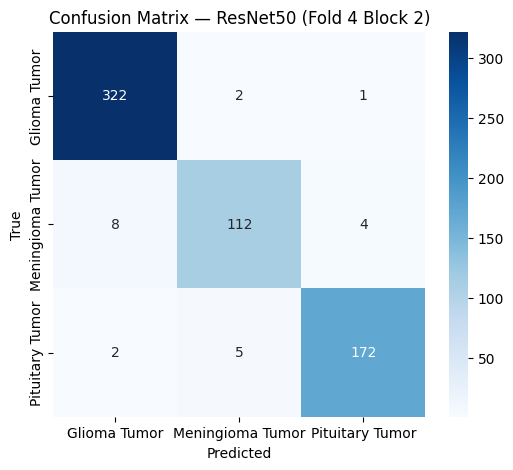

Fold: 4 block 1

Fold: 4 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,514,179
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0129 - accuracy: 0.9848 | val_loss: 0.0661 - val_accuracy: 0.9586
val_accuracy improved from 0.0000 to 0.9586, saving weights to /kaggle/working/ResNet50_block_1_fold_4.pth


Epoch 2/50 | loss: 0.0061 - accuracy: 0.9922 | val_loss: 0.0619 - val_accuracy: 0.9570
val_accuracy did not improve from 0.9586


Epoch 3/50 | loss: 0.0019 - accuracy: 0.9975 | val_loss: 0.0833 - val_accuracy: 0.9443
val_accuracy did not improve from 0.9586


Epoch 4/50 | loss: 0.0123 - accuracy: 0.9865 | val_loss: 0.0577 - val_accuracy: 0.9506
val_accuracy did not improve from 0.9586


Epoch 5/50 | loss: 0.0054 - accuracy: 0.9930 | val_loss: 0.0688 - val_accuracy: 0.9522
val_accuracy did not improve from 0.9586


Epoch 6/50 | loss: 0.0111 - accuracy: 0.9885 | val_loss: 0.0939 - val_accuracy: 0.9459
val_accuracy did not improve from 0.9586


Epoch 7/50 | loss: 0.0129 - accuracy: 0.9877 | val_loss: 0.0639 - val_accuracy: 0.9363
val_accuracy did not improve from 0.9586
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.066101  0.958599
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.99      0.97       325
Meningioma Tumor       0.91      0.90      0.90       124
 Pituitary Tumor       0.99      0.94      0.97       179

        accuracy                           0.96       628
       macro avg       0.95      0.94      0.95       628
    weighted avg       0.96      0.96      0.96       628



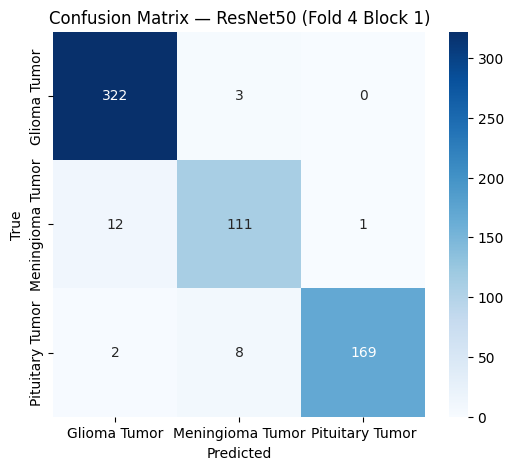

Fold: 5 block 6

Fold: 5 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     (23,508,032)         False
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 6,147
Non-trainable params: 23,508,032
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backward 

Epoch 1/50 | loss: 0.4420 - accuracy: 0.4895 | val_loss: 0.4135 - val_accuracy: 0.6065
val_accuracy improved from 0.0000 to 0.6065, saving weights to /kaggle/working/ResNet50_block_6_fold_5.pth


Epoch 2/50 | loss: 0.3175 - accuracy: 0.6828 | val_loss: 0.3304 - val_accuracy: 0.6952
val_accuracy improved from 0.6065 to 0.6952, saving weights to /kaggle/working/ResNet50_block_6_fold_5.pth


Epoch 3/50 | loss: 0.2661 - accuracy: 0.7418 | val_loss: 0.3067 - val_accuracy: 0.6890
val_accuracy did not improve from 0.6952


Epoch 4/50 | loss: 0.2361 - accuracy: 0.7670 | val_loss: 0.2874 - val_accuracy: 0.7185
val_accuracy improved from 0.6952 to 0.7185, saving weights to /kaggle/working/ResNet50_block_6_fold_5.pth


...

Epoch 12/50 | loss: 0.1619 - accuracy: 0.8335 | val_loss: 0.2146 - val_accuracy: 0.7760
val_accuracy did not improve from 0.7854


Epoch 13/50 | loss: 0.1600 - accuracy: 0.8319 | val_loss: 0.2322 - val_accuracy: 0.7527
val_accuracy did not improve from 0.7854


Epoch 14/50 | loss: 0.1559 - accuracy: 0.8311 | val_loss: 0.2285 - val_accuracy: 0.7543
val_accuracy did not improve from 0.7854


Epoch 15/50 | loss: 0.1599 - accuracy: 0.8286 | val_loss: 0.2114 - val_accuracy: 0.7698
val_accuracy did not improve from 0.7854


Epoch 16/50 | loss: 0.1489 - accuracy: 0.8393 | val_loss: 0.2128 - val_accuracy: 0.7729
val_accuracy did not improve from 0.7854
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.210531  0.785381
                  precision    recall  f1-score   support

    Glioma Tumor       0.82      0.85      0.84       287
Meningioma Tumor       0.69      0.49      0.58       166
 Pituitary Tumor       0.79      0.94      0.86       190

        accuracy                           0.79       643
       macro avg       0.77      0.76      0.76       643
    weighted avg       0.78      0.79      0.78       643



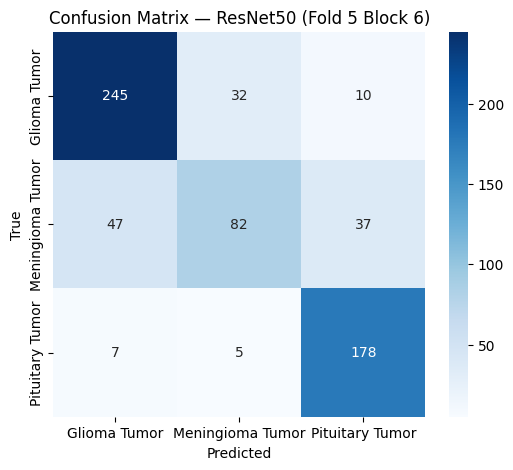

Fold: 5 block 5

Fold: 5 - Block 5
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 14,970,883
Non-trainable params: 8,543,296
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.1367 - accuracy: 0.8505 | val_loss: 0.1784 - val_accuracy: 0.8196
val_accuracy improved from 0.0000 to 0.8196, saving weights to /kaggle/working/ResNet50_block_5_fold_5.pth


Epoch 2/50 | loss: 0.0895 - accuracy: 0.8765 | val_loss: 0.2285 - val_accuracy: 0.7729
val_accuracy did not improve from 0.8196


Epoch 3/50 | loss: 0.0872 - accuracy: 0.9017 | val_loss: 0.2183 - val_accuracy: 0.8227
val_accuracy improved from 0.8196 to 0.8227, saving weights to /kaggle/working/ResNet50_block_5_fold_5.pth


Epoch 4/50 | loss: 0.0659 - accuracy: 0.9257 | val_loss: 0.1459 - val_accuracy: 0.8554
val_accuracy improved from 0.8227 to 0.8554, saving weights to /kaggle/working/ResNet50_block_5_fold_5.pth


...

Epoch 20/50 | loss: 0.0233 - accuracy: 0.9748 | val_loss: 0.1576 - val_accuracy: 0.8787
val_accuracy did not improve from 0.8865


Epoch 21/50 | loss: 0.0192 - accuracy: 0.9756 | val_loss: 0.1568 - val_accuracy: 0.8849
val_accuracy did not improve from 0.8865


Epoch 22/50 | loss: 0.0210 - accuracy: 0.9727 | val_loss: 0.1566 - val_accuracy: 0.8849
val_accuracy did not improve from 0.8865


Epoch 23/50 | loss: 0.0217 - accuracy: 0.9715 | val_loss: 0.1567 - val_accuracy: 0.8849
val_accuracy did not improve from 0.8865


Epoch 24/50 | loss: 0.0242 - accuracy: 0.9740 | val_loss: 0.1565 - val_accuracy: 0.8834
val_accuracy did not improve from 0.8865
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.154684   0.88647
                  precision    recall  f1-score   support

    Glioma Tumor       0.96      0.90      0.93       287
Meningioma Tumor       0.81      0.78      0.79       166
 Pituitary Tumor       0.85      0.96      0.90       190

        accuracy                           0.89       643
       macro avg       0.87      0.88      0.88       643
    weighted avg       0.89      0.89      0.89       643



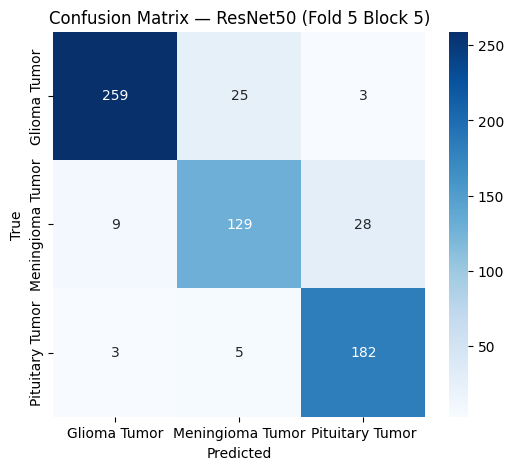

Fold: 5 block 4

Fold: 5 - Block 4
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 22,069,251
Non-trainable params: 1,444,928
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/bac

Epoch 1/50 | loss: 0.0342 - accuracy: 0.9612 | val_loss: 0.2053 - val_accuracy: 0.8585
val_accuracy improved from 0.0000 to 0.8585, saving weights to /kaggle/working/ResNet50_block_4_fold_5.pth


Epoch 2/50 | loss: 0.0340 - accuracy: 0.9575 | val_loss: 0.1758 - val_accuracy: 0.8647
val_accuracy improved from 0.8585 to 0.8647, saving weights to /kaggle/working/ResNet50_block_4_fold_5.pth


Epoch 3/50 | loss: 0.0289 - accuracy: 0.9620 | val_loss: 0.2273 - val_accuracy: 0.8445
val_accuracy did not improve from 0.8647


Epoch 4/50 | loss: 0.0216 - accuracy: 0.9748 | val_loss: 0.1755 - val_accuracy: 0.8834
val_accuracy improved from 0.8647 to 0.8834, saving weights to /kaggle/working/ResNet50_block_4_fold_5.pth


...

Epoch 14/50 | loss: 0.0038 - accuracy: 0.9963 | val_loss: 0.1762 - val_accuracy: 0.8974
val_accuracy did not improve from 0.9082


Epoch 15/50 | loss: 0.0040 - accuracy: 0.9971 | val_loss: 0.1824 - val_accuracy: 0.8989
val_accuracy did not improve from 0.9082


Epoch 16/50 | loss: 0.0036 - accuracy: 0.9959 | val_loss: 0.1768 - val_accuracy: 0.8958
val_accuracy did not improve from 0.9082


Epoch 17/50 | loss: 0.0037 - accuracy: 0.9955 | val_loss: 0.1744 - val_accuracy: 0.8989
val_accuracy did not improve from 0.9082


Epoch 18/50 | loss: 0.0028 - accuracy: 0.9967 | val_loss: 0.1787 - val_accuracy: 0.8974
val_accuracy did not improve from 0.9082
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.172975  0.908243
                  precision    recall  f1-score   support

    Glioma Tumor       0.94      0.95      0.95       287
Meningioma Tumor       0.90      0.76      0.82       166
 Pituitary Tumor       0.87      0.97      0.92       190

        accuracy                           0.91       643
       macro avg       0.90      0.89      0.90       643
    weighted avg       0.91      0.91      0.91       643



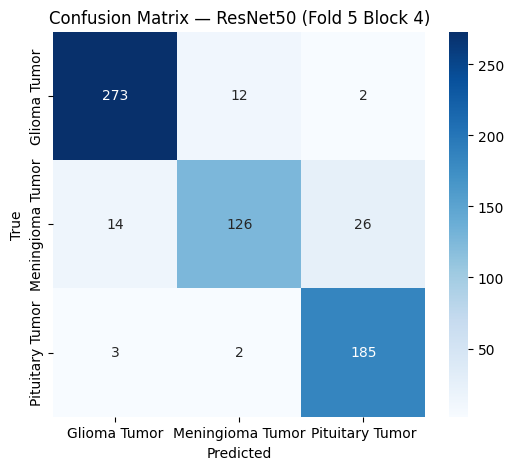

Fold: 5 block 3

Fold: 5 - Block 3
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,288,835
Non-trainable params: 225,344
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backw

Epoch 1/50 | loss: 0.0172 - accuracy: 0.9818 | val_loss: 0.1568 - val_accuracy: 0.8974
val_accuracy improved from 0.0000 to 0.8974, saving weights to /kaggle/working/ResNet50_block_3_fold_5.pth


Epoch 2/50 | loss: 0.0120 - accuracy: 0.9893 | val_loss: 0.2291 - val_accuracy: 0.8694
val_accuracy did not improve from 0.8974


Epoch 3/50 | loss: 0.0156 - accuracy: 0.9806 | val_loss: 0.1781 - val_accuracy: 0.8989
val_accuracy improved from 0.8974 to 0.8989, saving weights to /kaggle/working/ResNet50_block_3_fold_5.pth


Epoch 4/50 | loss: 0.0058 - accuracy: 0.9930 | val_loss: 0.1485 - val_accuracy: 0.9067
val_accuracy improved from 0.8989 to 0.9067, saving weights to /kaggle/working/ResNet50_block_3_fold_5.pth


...

Epoch 11/50 | loss: 0.0034 - accuracy: 0.9983 | val_loss: 0.1700 - val_accuracy: 0.9067
val_accuracy did not improve from 0.9145


Epoch 12/50 | loss: 0.0021 - accuracy: 0.9992 | val_loss: 0.1649 - val_accuracy: 0.9067
val_accuracy did not improve from 0.9145


Epoch 13/50 | loss: 0.0010 - accuracy: 0.9996 | val_loss: 0.1761 - val_accuracy: 0.9067
val_accuracy did not improve from 0.9145


Epoch 14/50 | loss: 0.0012 - accuracy: 0.9988 | val_loss: 0.1725 - val_accuracy: 0.9051
val_accuracy did not improve from 0.9145


Epoch 15/50 | loss: 0.0014 - accuracy: 0.9983 | val_loss: 0.1807 - val_accuracy: 0.9067
val_accuracy did not improve from 0.9145
early stopping, restoring model weights from the end of the best epoch
      Model     Loss  Accuracy
0  ResNet50  0.14229  0.914463
                  precision    recall  f1-score   support

    Glioma Tumor       0.97      0.93      0.95       287
Meningioma Tumor       0.86      0.83      0.84       166
 Pituitary Tumor       0.88      0.97      0.93       190

        accuracy                           0.91       643
       macro avg       0.90      0.91      0.91       643
    weighted avg       0.92      0.91      0.91       643



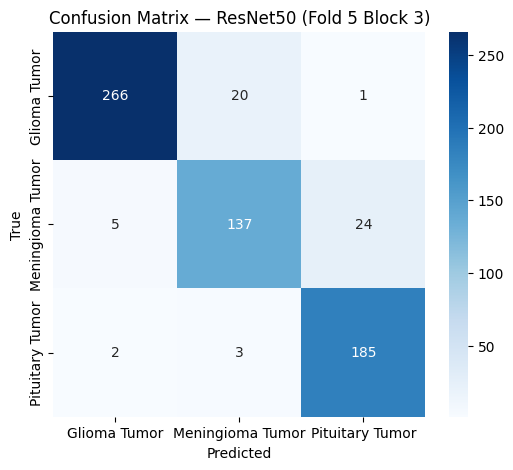

Fold: 5 block 2

Fold: 5 - Block 2
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           Partial
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,504,643
Non-trainable params: 9,536
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backwar

Epoch 1/50 | loss: 0.0090 - accuracy: 0.9905 | val_loss: 0.1699 - val_accuracy: 0.9098
val_accuracy improved from 0.0000 to 0.9098, saving weights to /kaggle/working/ResNet50_block_2_fold_5.pth


Epoch 2/50 | loss: 0.0096 - accuracy: 0.9880 | val_loss: 0.1630 - val_accuracy: 0.8880
val_accuracy did not improve from 0.9098


Epoch 3/50 | loss: 0.0100 - accuracy: 0.9868 | val_loss: 0.2250 - val_accuracy: 0.8896
val_accuracy did not improve from 0.9098


Epoch 4/50 | loss: 0.0031 - accuracy: 0.9971 | val_loss: 0.1993 - val_accuracy: 0.9036
val_accuracy did not improve from 0.9098


Epoch 5/50 | loss: 0.0157 - accuracy: 0.9835 | val_loss: 0.2034 - val_accuracy: 0.8927
val_accuracy did not improve from 0.9098


Epoch 6/50 | loss: 0.0066 - accuracy: 0.9922 | val_loss: 0.1683 - val_accuracy: 0.8911
val_accuracy did not improve from 0.9098


Epoch 7/50 | loss: 0.0037 - accuracy: 0.9959 | val_loss: 0.1883 - val_accuracy: 0.9067
val_accuracy did not improve from 0.9098
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.169903  0.909798
                  precision    recall  f1-score   support

    Glioma Tumor       0.98      0.91      0.94       287
Meningioma Tumor       0.83      0.84      0.84       166
 Pituitary Tumor       0.88      0.97      0.92       190

        accuracy                           0.91       643
       macro avg       0.90      0.91      0.90       643
    weighted avg       0.91      0.91      0.91       643



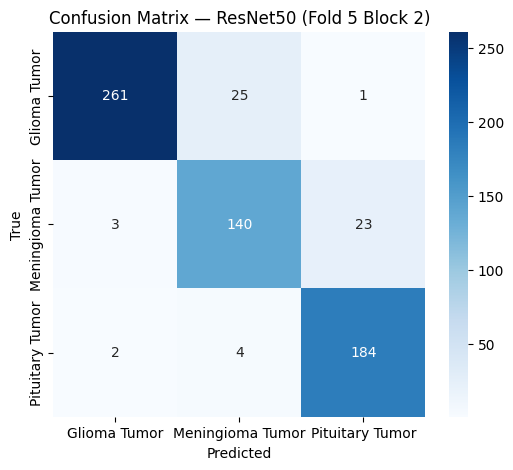

Fold: 5 block 1

Fold: 5 - Block 1
Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ResNet50 (ResNet50)                           [32, 3, 224, 224]    [32, 3]              --                   True
├─Sequential (features)                       [32, 3, 224, 224]    [32, 2048, 7, 7]     23,508,032           True
├─AdaptiveAvgPool2d (global_avg_pool)         [32, 2048, 7, 7]     [32, 2048, 1, 1]     --                   --
├─Flatten (flatten)                           [32, 2048, 1, 1]     [32, 2048]           --                   --
├─Dropout (dropout)                           [32, 2048]           [32, 2048]           --                   --
├─Linear (classifier)                         [32, 2048]           [32, 3]              6,147                True
Total params: 23,514,179
Trainable params: 23,514,179
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 130.79
Input size (MB): 19.27
Forward/backward pass siz

Epoch 1/50 | loss: 0.0095 - accuracy: 0.9897 | val_loss: 0.2022 - val_accuracy: 0.9067
val_accuracy improved from 0.0000 to 0.9067, saving weights to /kaggle/working/ResNet50_block_1_fold_5.pth


Epoch 2/50 | loss: 0.0060 - accuracy: 0.9938 | val_loss: 0.2159 - val_accuracy: 0.8865
val_accuracy did not improve from 0.9067


Epoch 3/50 | loss: 0.0095 - accuracy: 0.9880 | val_loss: 0.1567 - val_accuracy: 0.9176
val_accuracy improved from 0.9067 to 0.9176, saving weights to /kaggle/working/ResNet50_block_1_fold_5.pth


Epoch 4/50 | loss: 0.0040 - accuracy: 0.9959 | val_loss: 0.1534 - val_accuracy: 0.9160
val_accuracy did not improve from 0.9176


Epoch 5/50 | loss: 0.0039 - accuracy: 0.9955 | val_loss: 0.2022 - val_accuracy: 0.9036
val_accuracy did not improve from 0.9176


Epoch 6/50 | loss: 0.0041 - accuracy: 0.9942 | val_loss: 0.2195 - val_accuracy: 0.9067
val_accuracy did not improve from 0.9176


Epoch 7/50 | loss: 0.0107 - accuracy: 0.9860 | val_loss: 0.1311 - val_accuracy: 0.9082
val_accuracy did not improve from 0.9176


Epoch 8/50 | loss: 0.0034 - accuracy: 0.9959 | val_loss: 0.1754 - val_accuracy: 0.9145
val_accuracy did not improve from 0.9176


Epoch 9/50 | loss: 0.0073 - accuracy: 0.9905 | val_loss: 0.1611 - val_accuracy: 0.9114
val_accuracy did not improve from 0.9176
early stopping, restoring model weights from the end of the best epoch
      Model      Loss  Accuracy
0  ResNet50  0.156683  0.917574
                  precision    recall  f1-score   support

    Glioma Tumor       0.95      0.95      0.95       287
Meningioma Tumor       0.90      0.80      0.84       166
 Pituitary Tumor       0.88      0.97      0.92       190

        accuracy                           0.92       643
       macro avg       0.91      0.91      0.91       643
    weighted avg       0.92      0.92      0.92       643



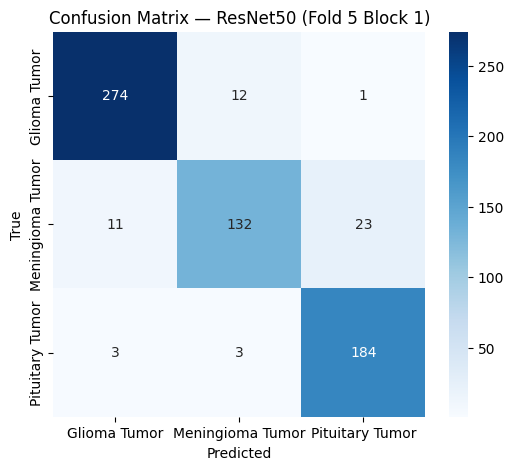

In [18]:
acc_b1, acc_b2, acc_b3, acc_b4, acc_b5, acc_b6 = [], [], [], [], [], []

for fold_k in range(1, 6):
    print(f'Fold: {fold_k} block 6')
    train_loader, val_loader = get_data_for_fold(k=fold_k)

    acc_b6.append(test_classifier(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k))

    torch.cuda.empty_cache()
    gc.collect()

    for block in range(5, 0, -1):
        print(f'Fold: {fold_k} block {block}')
        acc_list = [None, acc_b1, acc_b2, acc_b3, acc_b4, acc_b5]
        acc_list[block].append(test_block(train_loader=train_loader, val_loader=val_loader, fold_k=fold_k, block=block))

        torch.cuda.empty_cache()
        gc.collect()

    del train_loader, val_loader
    torch.cuda.empty_cache()
    gc.collect()

In [19]:
ACC_BLOCK = [acc_b6, acc_b5, acc_b4, acc_b3, acc_b2, acc_b1]

for _, acc in enumerate(ACC_BLOCK):
    print(f'Accuracy unfreeze block {6 - _} - block 6: {np.mean(acc) * 100:.2f}%')

Accuracy unfreeze block 6 - block 6: 82.51%
Accuracy unfreeze block 5 - block 6: 91.09%
Accuracy unfreeze block 4 - block 6: 92.99%
Accuracy unfreeze block 3 - block 6: 94.79%
Accuracy unfreeze block 2 - block 6: 94.88%
Accuracy unfreeze block 1 - block 6: 94.99%
